# **Optimized and Explainable Machine Learning for Coconut Fiber Concrete Strength Using SHAP, PDP, and ICE**

**Frequency Histograms**

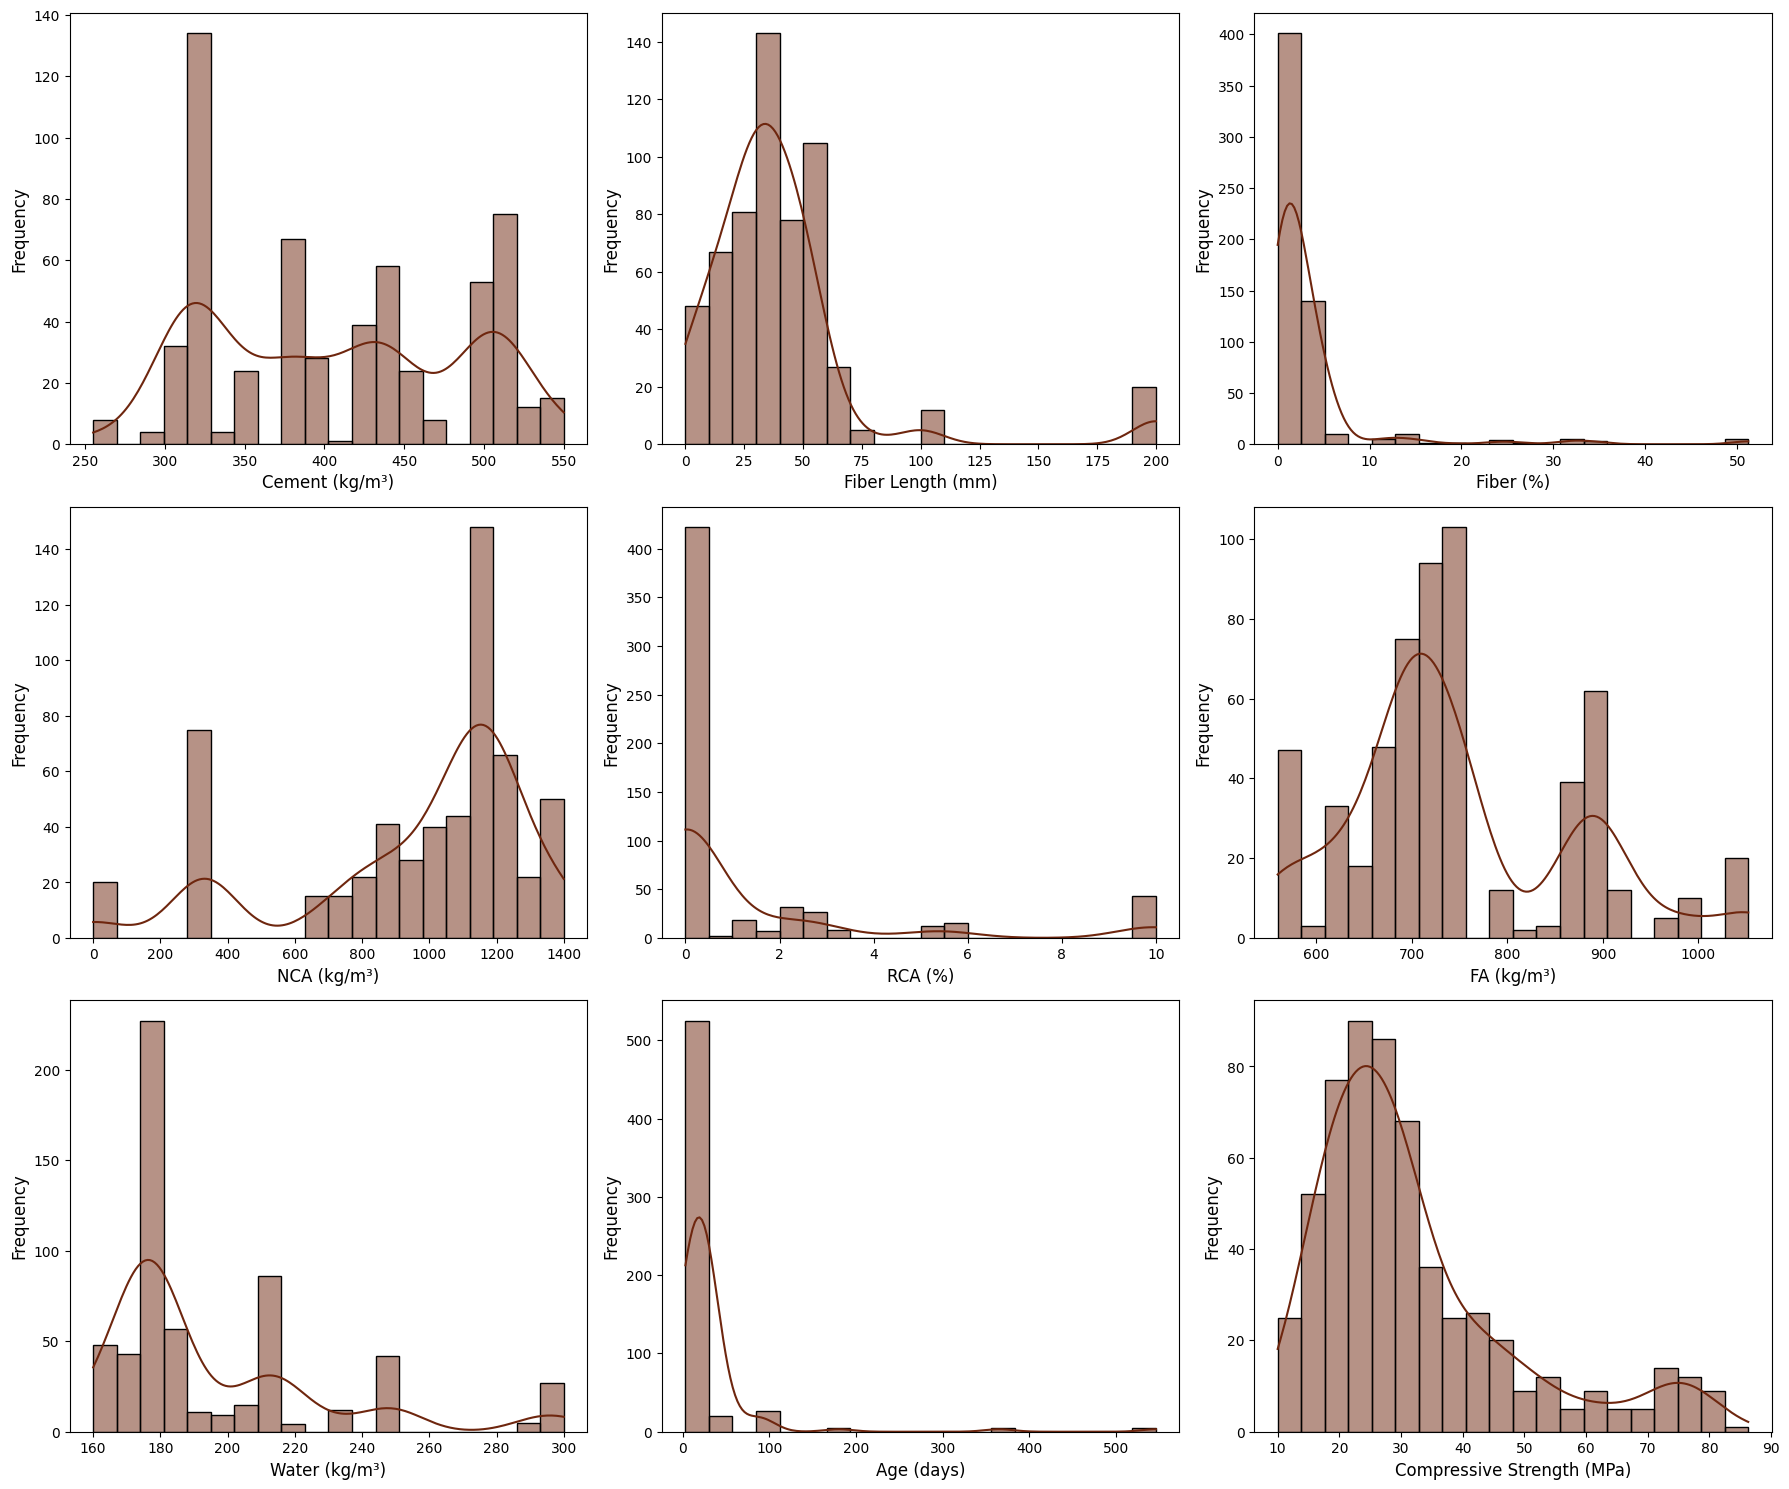

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel("Coconut fiber data.xlsx")

#coconut fiber inspired color
fiber_color = "#6E260E"

features = ['Cement (kg/m³)', 'Fiber Length (mm)', 'Fiber (%)', 'NCA (kg/m³)', 'RCA (%)', 'FA (kg/m³)', 'Water (kg/m³)', 'Age (days)', 'Compressive Strength (MPa)']


fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
for ax, feature in zip(axes, features):
    sns.histplot(data[feature], kde=True, color=fiber_color, bins=20, ax=ax)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('All_Histograms_Coconut_Fiber.png', dpi=600)
plt.show()


**Multicollinearity Analysis**

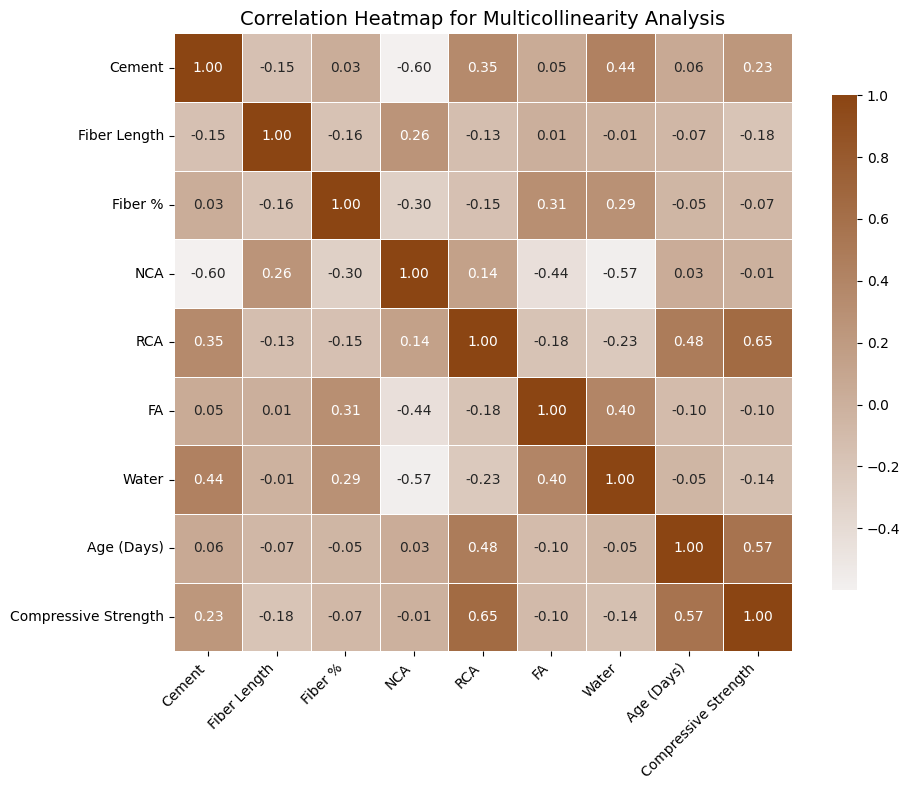

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_excel("Coconut fiber data.xlsx")

# Compute the correlation matrix
corr_matrix = data.corr()

# Set the coconut-inspired colormap: from light tan to dark brown
cmap = sns.light_palette("#8B4513", as_cmap=True)  # SaddleBrown tone

# Set the plot size
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap=cmap, fmt=".2f", linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 10})

plt.title("Correlation Heatmap for Multicollinearity Analysis", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("multicollinearity_heatmap.png", dpi=600)
plt.show()

**Nested CV + Hyperparameter Selection + Ablation Curves + Regression Plots on 30% locked out Test Dataset**

**Support Vector Machine**

  Preparing metadata (setup.py) ... done

=== Outer Fold 1/5 ===
Stopping search: maximum iterations reached --> 25
Fold 1 PSO done in 0.70 min → C=513.4, eps=0.001, gamma=0.2935

=== Outer Fold 2/5 ===
Stopping search: maximum iterations reached --> 25
Fold 2 PSO done in 0.75 min → C=1000, eps=1, gamma=0.3517

=== Outer Fold 3/5 ===
Stopping search: maximum iterations reached --> 25
Fold 3 PSO done in 0.90 min → C=942, eps=1, gamma=0.79

=== Outer Fold 4/5 ===
Stopping search: maximum iterations reached --> 25
Fold 4 PSO done in 0.56 min → C=285.3, eps=1, gamma=0.6174

=== Outer Fold 5/5 ===
Stopping search: maximum iterations reached --> 25
Fold 5 PSO done in 0.65 min → C=1000, eps=0.9999, gamma=0.1441


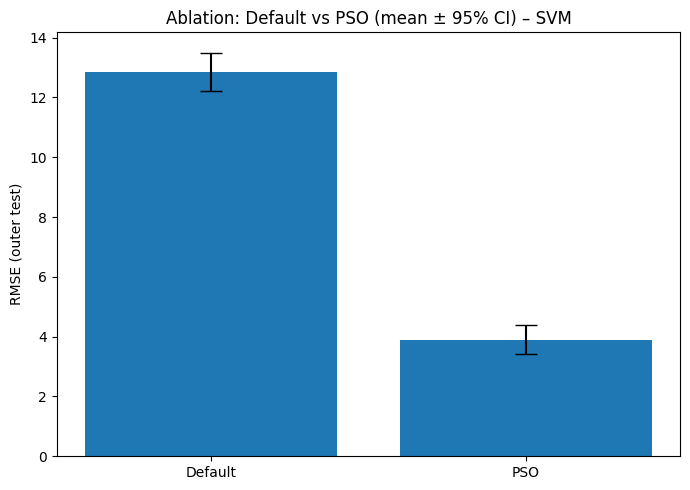


Final Locked Test Metrics (unseen 30%):
R²=0.9319, RMSE=4.476, MAE=3.091, MAPE=10.65%, MedAE=1.976


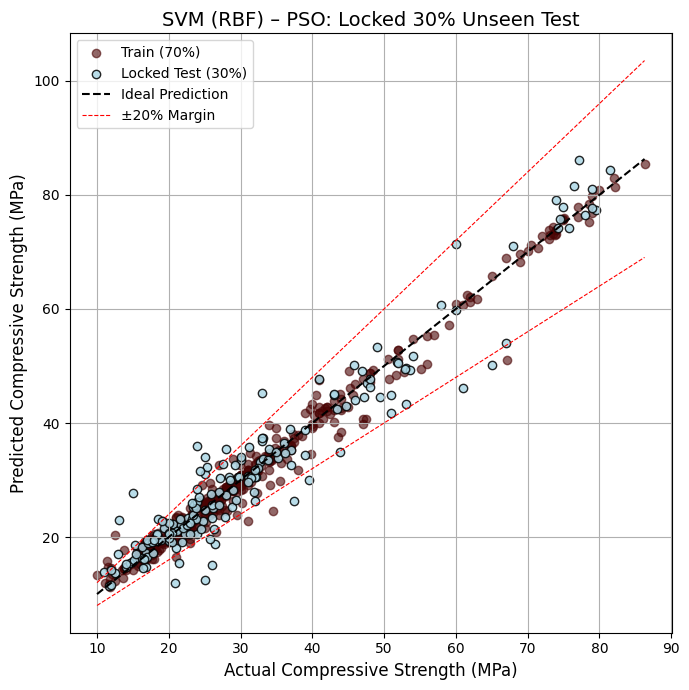


All results saved in: svm_pso_grouped_nestedcv_outputs


In [ ]:

!pip -q install pyswarm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.svm import SVR
from pyswarm import pso
from scipy.stats import bootstrap

OUT_DIR = "svm_pso_grouped_nestedcv_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED  = 42

# PSO meta-parameters
PSO_CONFIG = dict(swarmsize=20, maxiter=25, omega=0.7, phip=1.5, phig=1.5)

# Search bounds for SVM(RBF): [C, epsilon, gamma]
LB = [1e-2, 1e-3, 1e-4]
UB = [1e+3, 1.0,  1.0]

#load Dataset
df = pd.read_excel("Coconut fiber data.xlsx")
X = df.drop(columns=["Compressive Strength"])
y = df["Compressive Strength"]
# group by study/source if available; else use row index
groups = df["Source"].reset_index(drop=True) if "Source" in df.columns else pd.Series(np.arange(len(df)))

#split: locked 30% test by study
gss = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_all, X_test_locked = X.iloc[train_idx], X.iloc[test_idx]
y_train_all, y_test_locked = y.iloc[train_idx], y.iloc[test_idx]
groups_train_all, groups_test_locked = groups.iloc[train_idx], groups.iloc[test_idx]

#Evaluation Metrics
def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    medae = np.median(np.abs(y_true - y_pred))
    return r2, rmse, mae, mape, medae

def svr_inner_rmse(params, X_tr, y_tr, g_tr):
    C, eps, gam = params
    model = SVR(kernel="rbf", C=float(C), epsilon=float(eps), gamma=float(gam))
    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []
    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        scaler = StandardScaler()
        X_t = scaler.fit_transform(X_tr.iloc[tr_i])
        X_v = scaler.transform(X_tr.iloc[val_i])
        y_t, y_v = y_tr.iloc[tr_i], y_tr.iloc[val_i]
        model.fit(X_t, y_t)
        preds = model.predict(X_v)
        rmses.append(np.sqrt(mean_squared_error(y_v, preds)))
    return np.mean(rmses)

#Outer CV (k=5)
outer_cv = GroupKFold(n_splits=OUTER_SPLITS)
oof_rows, tr_rows, fold_metrics, per_fold_params = [], [], [], []
rmse_default_per_fold, rmse_pso_per_fold = [], []   # for ablation

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_train_all, y_train_all, groups_train_all), 1):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")
    X_tr, X_te = X_train_all.iloc[tr_idx], X_train_all.iloc[te_idx]
    y_tr, y_te = y_train_all.iloc[tr_idx], y_train_all.iloc[te_idx]
    g_tr, g_te = groups_train_all.iloc[tr_idx], groups_train_all.iloc[te_idx]

    #PSO on inner CV (k=5)
    t0 = time.time()
    obj = lambda p: svr_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)
    t_min = (time.time() - t0) / 60.0
    print(f"Fold {fold} PSO done in {t_min:.2f} min → C={opt_params[0]:.4g}, eps={opt_params[1]:.4g}, gamma={opt_params[2]:.4g}")

    per_fold_params.append({"fold": fold,
                            "best_params": {"C": float(opt_params[0]),
                                            "epsilon": float(opt_params[1]),
                                            "gamma": float(opt_params[2])}})

    #training
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    model_pso = SVR(kernel="rbf", **per_fold_params[-1]["best_params"])
    model_pso.fit(X_tr_s, y_tr)

    # predictions (PSO)
    y_tr_pred = model_pso.predict(X_tr_s)
    y_te_pred = model_pso.predict(X_te_s)

    tr_rows.append(pd.DataFrame({"fold": fold, "role": "train",
                                 "y_true": y_tr.values, "y_pred": y_tr_pred}))
    oof_rows.append(pd.DataFrame({"fold": fold, "role": "test",
                                  "y_true": y_te.values, "y_pred": y_te_pred}))

    r2t, rmset, maet, mapet, medaet = evaluate(y_te, y_te_pred)
    fold_metrics.append({"fold": fold, "r2": r2t, "rmse": rmset, "mae": maet,
                         "mape": mapet, "medae": medaet, "time_min": t_min})
    rmse_pso_per_fold.append(rmset)


    model_def = SVR(kernel="rbf")  # defaults: C=1.0, epsilon=0.1, gamma='scale'
    model_def.fit(X_tr_s, y_tr)
    y_te_def = model_def.predict(X_te_s)
    rmse_default_per_fold.append(np.sqrt(mean_squared_error(y_te, y_te_def)))


oof_df = pd.concat(oof_rows, ignore_index=True)
tr_df  = pd.concat(tr_rows,  ignore_index=True)
oof_df.to_csv(f"{OUT_DIR}/oof_predictions_test.csv", index=False)
tr_df.to_csv (f"{OUT_DIR}/train_predictions_per_fold.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
ci95 = bootstrap((fold_df["rmse"].values,), np.mean, confidence_level=0.95, random_state=RANDOM_SEED)
fold_df["rmse_mean_ci95"] = f"{fold_df.rmse.mean():.3f} ± {(ci95.confidence_interval[1]-fold_df.rmse.mean()):.3f}"
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

with open(f"{OUT_DIR}/best_params_per_fold.json", "w") as f:
    json.dump(per_fold_params, f, indent=2)
bp_df = pd.DataFrame([{"fold": d["fold"], **d["best_params"]} for d in per_fold_params])
bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold_table.csv", index=False)
bp_summary = bp_df.drop(columns=["fold"]).agg(["mean","std"]).round(6)
bp_summary.to_csv(f"{OUT_DIR}/best_params_mean_std.csv")


summary_rows = []
for metric in ["r2","rmse","mae","mape","medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)
    summary_rows.append({"metric": metric.upper(), "mean": m, "std": s, "ci95": ci})
pd.DataFrame(summary_rows).to_csv(f"{OUT_DIR}/ci95_from_outer_folds.csv", index=False)


def boot_ci(stat_fn, df, n_resamples=1000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(df))
    stats = []
    for _ in range(n_resamples):
        samp = df.iloc[rng.choice(idx, size=len(idx), replace=True)]
        stats.append(stat_fn(samp))
    return np.quantile(stats, [0.025, 0.975])

r2_ci   = boot_ci(lambda d: r2_score(d["y_true"], d["y_pred"]), oof_df)
rmse_ci = boot_ci(lambda d: np.sqrt(mean_squared_error(d["y_true"], d["y_pred"])), oof_df)
mae_ci  = boot_ci(lambda d: mean_absolute_error(d["y_true"], d["y_pred"]), oof_df)
mdae_ci = boot_ci(lambda d: np.median(np.abs(d["y_true"] - d["y_pred"])), oof_df)

pd.DataFrame([
    {"metric":"R2",   "boot_ci_lower":r2_ci[0],   "boot_ci_upper":r2_ci[1]},
    {"metric":"RMSE", "boot_ci_lower":rmse_ci[0], "boot_ci_upper":rmse_ci[1]},
    {"metric":"MAE",  "boot_ci_lower":mae_ci[0],  "boot_ci_upper":mae_ci[1]},
    {"metric":"MdAE", "boot_ci_lower":mdae_ci[0], "boot_ci_upper":mdae_ci[1]},
]).to_csv(f"{OUT_DIR}/ci95_bootstrap.csv", index=False)

#Ablation Study
def ci95_width(values):
    b = bootstrap((np.array(values),), np.mean, confidence_level=0.95, random_state=RANDOM_SEED)
    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)
err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

plt.figure(figsize=(7,5))
plt.bar(["Default", "PSO"], [rmse_def_mean, rmse_pso_mean],
        yerr=[err_def, err_pso], capsize=8)
plt.ylabel("RMSE (outer test)")
plt.title("Ablation: Default vs PSO (mean ± 95% CI) – SVM")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600)
plt.show()

best_params_avg = bp_summary.loc["mean"].to_dict()
scaler_final = StandardScaler()
Xtr_s = scaler_final.fit_transform(X_train_all)
Xte_s = scaler_final.transform(X_test_locked)
final_model = SVR(kernel="rbf",
                  C=float(best_params_avg["C"]),
                  epsilon=float(best_params_avg["epsilon"]),
                  gamma=float(best_params_avg["gamma"]))
final_model.fit(Xtr_s, y_train_all)

y_train_pred_final = final_model.predict(Xtr_s)
y_test_pred_final  = final_model.predict(Xte_s)

# locked 30% test metrics
r2_t, rmse_t, mae_t, mape_t, medae_t = evaluate(y_test_locked, y_test_pred_final)
print("\nFinal Locked Test Metrics (unseen 30%):")
print(f"R²={r2_t:.4f}, RMSE={rmse_t:.3f}, MAE={mae_t:.3f}, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f}")

# save predictions
pd.DataFrame({"y_true": y_test_locked, "y_pred": y_test_pred_final}).to_csv(
    f"{OUT_DIR}/locked_test_predictions.csv", index=False
)

# Regression plot
plt.figure(figsize=(7,7))
plt.scatter(y_train_all, y_train_pred_final, color='#4A0404', alpha=0.6, label='Train (70%)')
plt.scatter(y_test_locked, y_test_pred_final, color='lightblue', edgecolor='k', alpha=0.85, label='Locked Test (30%)')

min_val = min(y.min(), y_test_pred_final.min())
max_val = max(y.max(), y_test_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal Prediction')
plt.plot([min_val, max_val], [min_val*1.2, max_val*1.2], 'r--', lw=0.8, label='±20% Margin')
plt.plot([min_val, max_val], [min_val*0.8, max_val*0.8], 'r--', lw=0.8)

plt.xlabel("Actual Compressive Strength (MPa)", fontsize=12)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=12)
plt.title("SVM (RBF) – PSO: Locked 30% Unseen Test", fontsize=14)
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/SVM_PSO_locked_test_regression.png", dpi=600)
plt.show()

print("\nAll results saved in:", OUT_DIR)


**K Nearest Neighbour**


=== Outer Fold 1/5 ===
Stopping search: maximum iterations reached --> 25
Fold 1 PSO done in 0.43 min → {'n_neighbors': 2, 'weights': 'distance', 'p': 1.1611863672236866, 'leaf_size': 38, 'metric': 'minkowski', 'algorithm': 'auto'}

=== Outer Fold 2/5 ===
Stopping search: maximum iterations reached --> 25
Fold 2 PSO done in 0.63 min → {'n_neighbors': 2, 'weights': 'uniform', 'p': 2.0376894077691894, 'leaf_size': 11, 'metric': 'minkowski', 'algorithm': 'auto'}

=== Outer Fold 3/5 ===
Stopping search: maximum iterations reached --> 25
Fold 3 PSO done in 0.61 min → {'n_neighbors': 3, 'weights': 'distance', 'p': 1.0042579742680584, 'leaf_size': 57, 'metric': 'minkowski', 'algorithm': 'auto'}

=== Outer Fold 4/5 ===
Stopping search: maximum iterations reached --> 25
Fold 4 PSO done in 0.30 min → {'n_neighbors': 3, 'weights': 'distance', 'p': 1.2540645406025428, 'leaf_size': 12, 'metric': 'minkowski', 'algorithm': 'auto'}

=== Outer Fold 5/5 ===
Stopping search: maximum iterations reached -

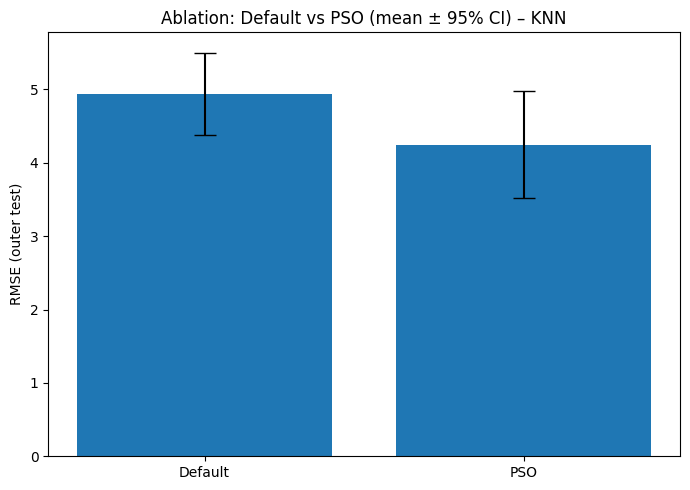


Final Locked Test Metrics (unseen 30%):
R²=0.9044, RMSE=5.302, MAE=3.629, MAPE=12.72%, MedAE=2.476
Final averaged KNN params: {'n_neighbors': 2, 'weights': 'distance', 'p': 1.300279, 'leaf_size': 29, 'metric': 'minkowski', 'algorithm': 'auto'}


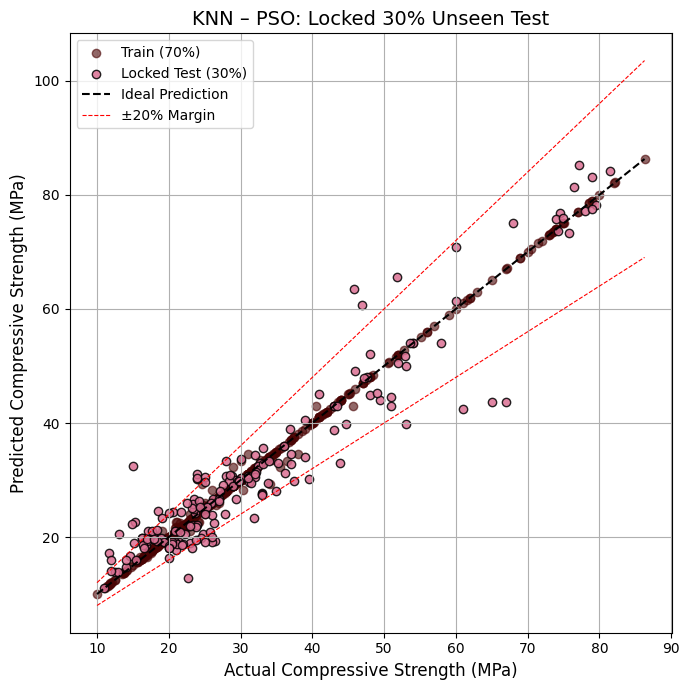


All results saved in: knn_pso_grouped_nestedcv_outputs


In [ ]:
#!pip -q install pyswarm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from pyswarm import pso
from scipy.stats import bootstrap

OUT_DIR = "knn_pso_grouped_nestedcv_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED  = 42

# PSO meta-parameters
PSO_CONFIG = dict(swarmsize=20, maxiter=25, omega=0.7, phip=1.5, phig=1.5)

#Bounds
LB = [1, 0.0, 1.0, 10]
UB = [60, 1.0, 3.0, 60]

df = pd.read_excel("Coconut fiber data.xlsx")
X = df.drop(columns=["Compressive Strength"])
y = df["Compressive Strength"]
groups = df["Source"].reset_index(drop=True) if "Source" in df.columns else pd.Series(np.arange(len(df)))

gss = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_all, X_test_locked = X.iloc[train_idx], X.iloc[test_idx]
y_train_all, y_test_locked = y.iloc[train_idx], y.iloc[test_idx]
groups_train_all, groups_test_locked = groups.iloc[train_idx], groups.iloc[test_idx]

def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    medae = np.median(np.abs(y_true - y_pred))
    return r2, rmse, mae, mape, medae

def decode_knn_params(params):
    n_neighbors = int(round(params[0]))
    weights_flag = float(params[1])
    weights = "distance" if weights_flag >= 0.5 else "uniform"
    p = float(params[2])
    leaf_size = int(round(params[3]))
    n_neighbors = max(1, n_neighbors)
    leaf_size = max(10, leaf_size)
    return dict(n_neighbors=n_neighbors, weights=weights, p=p, leaf_size=leaf_size,
                metric="minkowski", algorithm="auto")

def knn_inner_rmse(params, X_tr, y_tr, g_tr):
    hp = decode_knn_params(params)
    model = KNeighborsRegressor(**hp)
    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []
    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        scaler = StandardScaler()
        X_t = scaler.fit_transform(X_tr.iloc[tr_i])
        X_v = scaler.transform(X_tr.iloc[val_i])
        y_t, y_v = y_tr.iloc[tr_i], y_tr.iloc[val_i]
        model.fit(X_t, y_t)
        preds = model.predict(X_v)
        rmses.append(np.sqrt(mean_squared_error(y_v, preds)))
    return np.mean(rmses)

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)
oof_rows, tr_rows, fold_metrics, per_fold_params = [], [], [], []
rmse_default_per_fold, rmse_pso_per_fold = [], []

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_train_all, y_train_all, groups_train_all), 1):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")
    X_tr, X_te = X_train_all.iloc[tr_idx], X_train_all.iloc[te_idx]
    y_tr, y_te = y_train_all.iloc[tr_idx], y_train_all.iloc[te_idx]
    g_tr, g_te = groups_train_all.iloc[tr_idx], groups_train_all.iloc[te_idx]

    t0 = time.time()
    obj = lambda p: knn_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)
    t_min = (time.time() - t0) / 60.0
    hp = decode_knn_params(opt_params)
    print(f"Fold {fold} PSO done in {t_min:.2f} min → {hp}")

    per_fold_params.append({"fold": fold, "best_params": hp})

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    model = KNeighborsRegressor(**hp)
    model.fit(X_tr_s, y_tr)

    y_tr_pred = model.predict(X_tr_s)
    y_te_pred = model.predict(X_te_s)

    tr_rows.append(pd.DataFrame({"fold": fold, "role": "train",
                                 "y_true": y_tr.values, "y_pred": y_tr_pred}))
    oof_rows.append(pd.DataFrame({"fold": fold, "role": "test",
                                  "y_true": y_te.values, "y_pred": y_te_pred}))

    r2t, rmset, maet, mapet, medaet = evaluate(y_te, y_te_pred)
    fold_metrics.append({"fold": fold, "r2": r2t, "rmse": rmset, "mae": maet,
                         "mape": mapet, "medae": medaet, "time_min": t_min})
    rmse_pso_per_fold.append(rmset)

    knn_default = KNeighborsRegressor()
    knn_default.fit(X_tr_s, y_tr)
    y_te_def = knn_default.predict(X_te_s)
    rmse_default_per_fold.append(np.sqrt(mean_squared_error(y_te, y_te_def)))

oof_df = pd.concat(oof_rows, ignore_index=True)
tr_df  = pd.concat(tr_rows,  ignore_index=True)
oof_df.to_csv(f"{OUT_DIR}/oof_predictions_test.csv", index=False)
tr_df.to_csv (f"{OUT_DIR}/train_predictions_per_fold.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
ci95 = bootstrap((fold_df["rmse"].values,), np.mean, confidence_level=0.95, random_state=RANDOM_SEED)
fold_df["rmse_mean_ci95"] = f"{fold_df.rmse.mean():.3f} ± {(ci95.confidence_interval[1]-fold_df.rmse.mean()):.3f}"
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

with open(f"{OUT_DIR}/best_params_per_fold.json", "w") as f:
    json.dump(per_fold_params, f, indent=2)

bp_df = pd.DataFrame([{"fold": d["fold"], **d["best_params"]} for d in per_fold_params])
bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold_table.csv", index=False)

bp_num = bp_df.copy()
bp_num["weights_num"] = (bp_num["weights"] == "distance").astype(float)

bp_summary = pd.DataFrame({
    "n_neighbors_mean": [bp_num["n_neighbors"].mean()],
    "n_neighbors_std":  [bp_num["n_neighbors"].std(ddof=1)],
    "weights_mean":     [bp_num["weights_num"].mean()],   # proportion "distance"
    "weights_std":      [bp_num["weights_num"].std(ddof=1)],
    "p_mean":           [bp_num["p"].mean()],
    "p_std":            [bp_num["p"].std(ddof=1)],
    "leaf_size_mean":   [bp_num["leaf_size"].mean()],
    "leaf_size_std":    [bp_num["leaf_size"].std(ddof=1)],
}).round(6)

bp_summary.to_csv(f"{OUT_DIR}/best_params_mean_std.csv", index=False)

summary_rows = []
for metric in ["r2","rmse","mae","mape","medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)
    summary_rows.append({"metric": metric.upper(), "mean": m, "std": s, "ci95": ci})
pd.DataFrame(summary_rows).to_csv(f"{OUT_DIR}/ci95_from_outer_folds.csv", index=False)

def boot_ci(stat_fn, df, n_resamples=1000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(df))
    stats = []
    for _ in range(n_resamples):
        samp = df.iloc[rng.choice(idx, size=len(idx), replace=True)]
        stats.append(stat_fn(samp))
    return np.quantile(stats, [0.025, 0.975])

r2_ci   = boot_ci(lambda d: r2_score(d["y_true"], d["y_pred"]), oof_df)
rmse_ci = boot_ci(lambda d: np.sqrt(mean_squared_error(d["y_true"], d["y_pred"])), oof_df)
mae_ci  = boot_ci(lambda d: mean_absolute_error(d["y_true"], d["y_pred"]), oof_df)
mdae_ci = boot_ci(lambda d: np.median(np.abs(d["y_true"] - d["y_pred"])), oof_df)

pd.DataFrame([
    {"metric":"R2",   "boot_ci_lower":r2_ci[0],   "boot_ci_upper":r2_ci[1]},
    {"metric":"RMSE", "boot_ci_lower":rmse_ci[0], "boot_ci_upper":rmse_ci[1]},
    {"metric":"MAE",  "boot_ci_lower":mae_ci[0],  "boot_ci_upper":mae_ci[1]},
    {"metric":"MdAE", "boot_ci_lower":mdae_ci[0], "boot_ci_upper":mdae_ci[1]},
]).to_csv(f"{OUT_DIR}/ci95_bootstrap.csv", index=False)

def ci95_width(values):
    b = bootstrap((np.array(values),), np.mean, confidence_level=0.95, random_state=RANDOM_SEED)
    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)
err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

plt.figure(figsize=(7,5))
plt.bar(["Default", "PSO"], [rmse_def_mean, rmse_pso_mean],
        yerr=[err_def, err_pso], capsize=8)
plt.ylabel("RMSE (outer test)")
plt.title("Ablation: Default vs PSO (mean ± 95% CI) – KNN")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600)
plt.show()

best_params_avg = bp_summary.iloc[0].to_dict()
avg_weights = "distance" if float(best_params_avg["weights_mean"]) >= 0.5 else "uniform"
final_hp = dict(
    n_neighbors = int(round(float(best_params_avg["n_neighbors_mean"]))),
    weights     = avg_weights,
    p           = float(best_params_avg["p_mean"]),
    leaf_size   = int(round(float(best_params_avg["leaf_size_mean"]))),
    metric      = "minkowski",
    algorithm   = "auto"
)

scaler_final = StandardScaler()
Xtr_s = scaler_final.fit_transform(X_train_all)
Xte_s = scaler_final.transform(X_test_locked)
final_model = KNeighborsRegressor(**final_hp)
final_model.fit(Xtr_s, y_train_all)

y_train_pred_final = final_model.predict(Xtr_s)
y_test_pred_final  = final_model.predict(Xte_s)

r2_t, rmse_t, mae_t, mape_t, medae_t = evaluate(y_test_locked, y_test_pred_final)
print("\nFinal Locked Test Metrics (unseen 30%):")
print(f"R²={r2_t:.4f}, RMSE={rmse_t:.3f}, MAE={mae_t:.3f}, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f}")
print("Final averaged KNN params:", final_hp)

pd.DataFrame({"y_true": y_test_locked, "y_pred": y_test_pred_final}).to_csv(
    f"{OUT_DIR}/locked_test_predictions.csv", index=False
)

plt.figure(figsize=(7,7))
plt.scatter(y_train_all, y_train_pred_final, color='#4A0404', alpha=0.6, label='Train (70%)')
plt.scatter(y_test_locked, y_test_pred_final, color='palevioletred', edgecolor='k', alpha=0.85, label='Locked Test (30%)')

min_val = min(y.min(), y_test_pred_final.min())
max_val = max(y.max(), y_test_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal Prediction')
plt.plot([min_val, max_val], [min_val*1.2, max_val*1.2], 'r--', lw=0.8, label='±20% Margin')
plt.plot([min_val, max_val], [min_val*0.8, max_val*0.8], 'r--', lw=0.8)

plt.xlabel("Actual Compressive Strength (MPa)", fontsize=12)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=12)
plt.title("KNN – PSO: Locked 30% Unseen Test", fontsize=14)
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/KNN_PSO_locked_test_regression.png", dpi=600)
plt.show()

print("\nAll results saved in:", OUT_DIR)


**Random Forest**

  Preparing metadata (setup.py) ... done

=== Outer Fold 1/5 ===
Stopping search: Swarm best objective change less than 1e-08
Fold 1 PSO done in 16.58 min → {'n_estimators': 471, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.336831433262995, 'random_state': 42, 'n_jobs': -1}

=== Outer Fold 2/5 ===
Stopping search: Swarm best objective change less than 1e-08
Fold 2 PSO done in 3.17 min → {'n_estimators': 500, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.2992197386801692, 'random_state': 42, 'n_jobs': -1}

=== Outer Fold 3/5 ===
Stopping search: Swarm best objective change less than 1e-08
Fold 3 PSO done in 9.43 min → {'n_estimators': 334, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.31018674155506976, 'random_state': 42, 'n_jobs': -1}

=== Outer Fold 4/5 ===
Stopping search: maximum iterations reached --> 25
Fold 4 PSO done in 19.63 min → {'n_estimators': 461, 'max_depth': 30, 

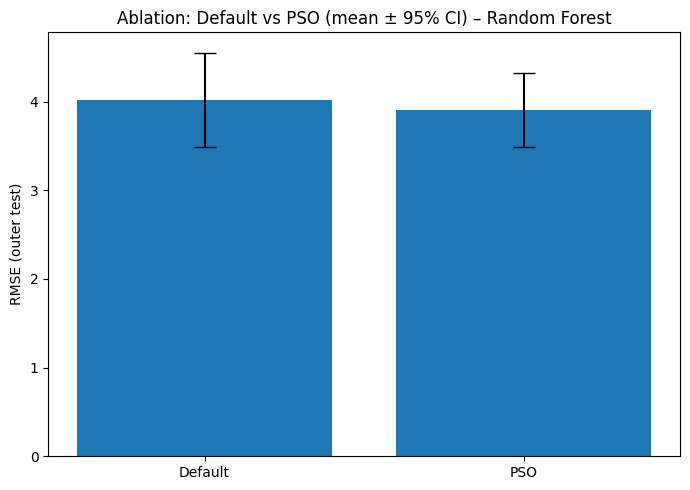


Final Locked Test Metrics (unseen 30%):
R²=0.9418, RMSE=4.138, MAE=3.032, MAPE=10.50%, MedAE=2.198
Final averaged RF params: {'n_estimators': 363, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.362219, 'random_state': 42, 'n_jobs': -1}


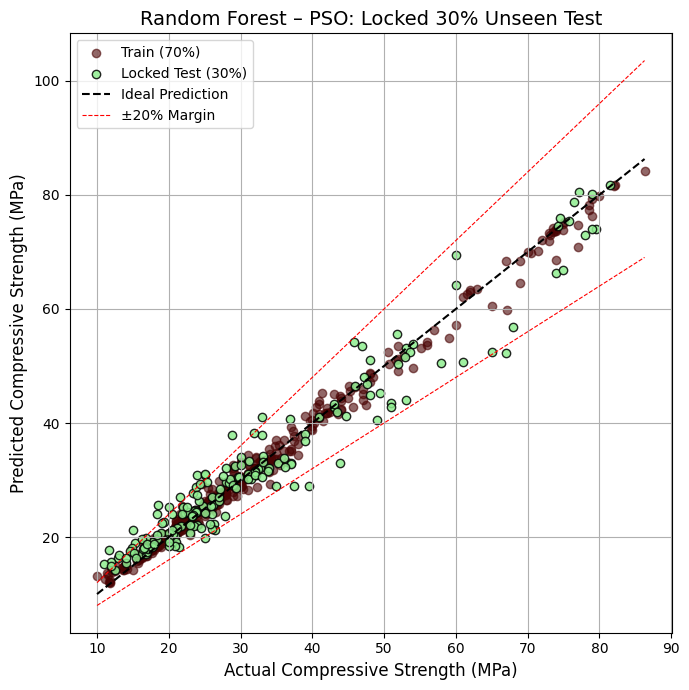


All results saved in: rf_pso_grouped_nestedcv_outputs_noscale


In [ ]:
#!pip -q install pyswarm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from pyswarm import pso
from scipy.stats import bootstrap

OUT_DIR = "rf_pso_grouped_nestedcv_outputs_noscale"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED  = 42

PSO_CONFIG = dict(swarmsize=20, maxiter=25, omega=0.7, phip=1.5, phig=1.5)

#Bounds
LB = [50, 2, 2, 1, 0.1]
UB = [500, 30, 20, 10, 1.0]

df = pd.read_excel("Coconut fiber data.xlsx")
X = df.drop(columns=["Compressive Strength"])
y = df["Compressive Strength"]
groups = df["Source"].reset_index(drop=True) if "Source" in df.columns else pd.Series(np.arange(len(df)))

gss = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_all, X_test_locked = X.iloc[train_idx], X.iloc[test_idx]
y_train_all, y_test_locked = y.iloc[train_idx], y.iloc[test_idx]
groups_train_all, groups_test_locked = groups.iloc[train_idx], groups.iloc[test_idx]

def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    medae = np.median(np.abs(y_true - y_pred))
    return r2, rmse, mae, mape, medae

def decode_rf_params(params):
    n_estimators = int(round(params[0]))
    max_depth = int(round(params[1]))
    min_samples_split = int(round(params[2]))
    min_samples_leaf = int(round(params[3]))
    max_features = float(params[4])
    max_depth = None if max_depth <= 1 else max_depth
    return dict(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

def rf_inner_rmse(params, X_tr, y_tr, g_tr):
    hp = decode_rf_params(params)
    model = RandomForestRegressor(**hp)
    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []
    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        X_t, X_v = X_tr.iloc[tr_i], X_tr.iloc[val_i]
        y_t, y_v = y_tr.iloc[tr_i], y_tr.iloc[val_i]
        model.fit(X_t, y_t)
        preds = model.predict(X_v)
        rmses.append(np.sqrt(mean_squared_error(y_v, preds)))
    return np.mean(rmses)

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)
oof_rows, tr_rows, fold_metrics, per_fold_params = [], [], [], []
rmse_default_per_fold, rmse_pso_per_fold = [], []

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_train_all, y_train_all, groups_train_all), 1):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")
    X_tr, X_te = X_train_all.iloc[tr_idx], X_train_all.iloc[te_idx]
    y_tr, y_te = y_train_all.iloc[tr_idx], y_train_all.iloc[te_idx]
    g_tr, g_te = groups_train_all.iloc[tr_idx], groups_train_all.iloc[te_idx]

    t0 = time.time()
    obj = lambda p: rf_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)
    t_min = (time.time() - t0) / 60.0
    hp = decode_rf_params(opt_params)
    print(f"Fold {fold} PSO done in {t_min:.2f} min → {hp}")

    per_fold_params.append({"fold": fold, "best_params": hp})

    model = RandomForestRegressor(**hp)
    model.fit(X_tr, y_tr)
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    tr_rows.append(pd.DataFrame({"fold": fold, "role": "train",
                                 "y_true": y_tr.values, "y_pred": y_tr_pred}))
    oof_rows.append(pd.DataFrame({"fold": fold, "role": "test",
                                  "y_true": y_te.values, "y_pred": y_te_pred}))

    r2t, rmset, maet, mapet, medaet = evaluate(y_te, y_te_pred)
    fold_metrics.append({"fold": fold, "r2": r2t, "rmse": rmset, "mae": maet,
                         "mape": mapet, "medae": medaet, "time_min": t_min})
    rmse_pso_per_fold.append(rmset)

    rf_default = RandomForestRegressor(random_state=RANDOM_SEED)
    rf_default.fit(X_tr, y_tr)
    y_te_def = rf_default.predict(X_te)
    rmse_default_per_fold.append(np.sqrt(mean_squared_error(y_te, y_te_def)))

oof_df = pd.concat(oof_rows, ignore_index=True)
tr_df  = pd.concat(tr_rows,  ignore_index=True)
oof_df.to_csv(f"{OUT_DIR}/oof_predictions_test.csv", index=False)
tr_df.to_csv (f"{OUT_DIR}/train_predictions_per_fold.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
ci95 = bootstrap((fold_df["rmse"].values,), np.mean, confidence_level=0.95, random_state=RANDOM_SEED)
fold_df["rmse_mean_ci95"] = f"{fold_df.rmse.mean():.3f} ± {(ci95.confidence_interval[1]-fold_df.rmse.mean()):.3f}"
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

with open(f"{OUT_DIR}/best_params_per_fold.json", "w") as f:
    json.dump(per_fold_params, f, indent=2)
bp_df = pd.DataFrame([{"fold": d["fold"], **d["best_params"]} for d in per_fold_params])
bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold_table.csv", index=False)
bp_summary = bp_df.drop(columns=["fold"]).agg(["mean","std"]).round(6)
bp_summary.to_csv(f"{OUT_DIR}/best_params_mean_std.csv")

summary_rows = []
for metric in ["r2","rmse","mae","mape","medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)
    summary_rows.append({"metric": metric.upper(), "mean": m, "std": s, "ci95": ci})
pd.DataFrame(summary_rows).to_csv(f"{OUT_DIR}/ci95_from_outer_folds.csv", index=False)

def boot_ci(stat_fn, df, n_resamples=1000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(df))
    stats = []
    for _ in range(n_resamples):
        samp = df.iloc[rng.choice(idx, size=len(idx), replace=True)]
        stats.append(stat_fn(samp))
    return np.quantile(stats, [0.025, 0.975])

r2_ci   = boot_ci(lambda d: r2_score(d["y_true"], d["y_pred"]), oof_df)
rmse_ci = boot_ci(lambda d: np.sqrt(mean_squared_error(d["y_true"], d["y_pred"])), oof_df)
mae_ci  = boot_ci(lambda d: mean_absolute_error(d["y_true"], d["y_pred"]), oof_df)
mdae_ci = boot_ci(lambda d: np.median(np.abs(d["y_true"] - d["y_pred"])), oof_df)

pd.DataFrame([
    {"metric":"R2",   "boot_ci_lower":r2_ci[0],   "boot_ci_upper":r2_ci[1]},
    {"metric":"RMSE", "boot_ci_lower":rmse_ci[0], "boot_ci_upper":rmse_ci[1]},
    {"metric":"MAE",  "boot_ci_lower":mae_ci[0],  "boot_ci_upper":mae_ci[1]},
    {"metric":"MdAE", "boot_ci_lower":mdae_ci[0], "boot_ci_upper":mdae_ci[1]},
]).to_csv(f"{OUT_DIR}/ci95_bootstrap.csv", index=False)

def ci95_width(values):
    b = bootstrap((np.array(values),), np.mean, confidence_level=0.95, random_state=RANDOM_SEED)
    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)
err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

plt.figure(figsize=(7,5))
plt.bar(["Default", "PSO"], [rmse_def_mean, rmse_pso_mean],
        yerr=[err_def, err_pso], capsize=8)
plt.ylabel("RMSE (outer test)")
plt.title("Ablation: Default vs PSO (mean ± 95% CI) – Random Forest")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600)
plt.show()

best_params_avg = bp_summary.loc["mean"].to_dict()
final_hp = decode_rf_params([
    best_params_avg["n_estimators"],
    best_params_avg["max_depth"],
    best_params_avg["min_samples_split"],
    best_params_avg["min_samples_leaf"],
    best_params_avg["max_features"]
])

final_model = RandomForestRegressor(**final_hp)
final_model.fit(X_train_all, y_train_all)
y_train_pred_final = final_model.predict(X_train_all)
y_test_pred_final  = final_model.predict(X_test_locked)

r2_t, rmse_t, mae_t, mape_t, medae_t = evaluate(y_test_locked, y_test_pred_final)
print("\nFinal Locked Test Metrics (unseen 30%):")
print(f"R²={r2_t:.4f}, RMSE={rmse_t:.3f}, MAE={mae_t:.3f}, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f}")
print("Final averaged RF params:", final_hp)

pd.DataFrame({"y_true": y_test_locked, "y_pred": y_test_pred_final}).to_csv(
    f"{OUT_DIR}/locked_test_predictions.csv", index=False
)

plt.figure(figsize=(7,7))
plt.scatter(y_train_all, y_train_pred_final, color='#4A0404', alpha=0.6, label='Train (70%)')
plt.scatter(y_test_locked, y_test_pred_final, color='lightgreen', edgecolor='k', alpha=0.85, label='Locked Test (30%)')

min_val = min(y.min(), y_test_pred_final.min())
max_val = max(y.max(), y_test_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal Prediction')
plt.plot([min_val, max_val], [min_val*1.2, max_val*1.2], 'r--', lw=0.8, label='±20% Margin')
plt.plot([min_val, max_val], [min_val*0.8, max_val*0.8], 'r--', lw=0.8)

plt.xlabel("Actual Compressive Strength (MPa)", fontsize=12)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=12)
plt.title("Random Forest – PSO: Locked 30% Unseen Test", fontsize=14)
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/RF_PSO_locked_test_regression.png", dpi=600)
plt.show()

print("\nAll results saved in:", OUT_DIR)


**Light Gradient Boosting**

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

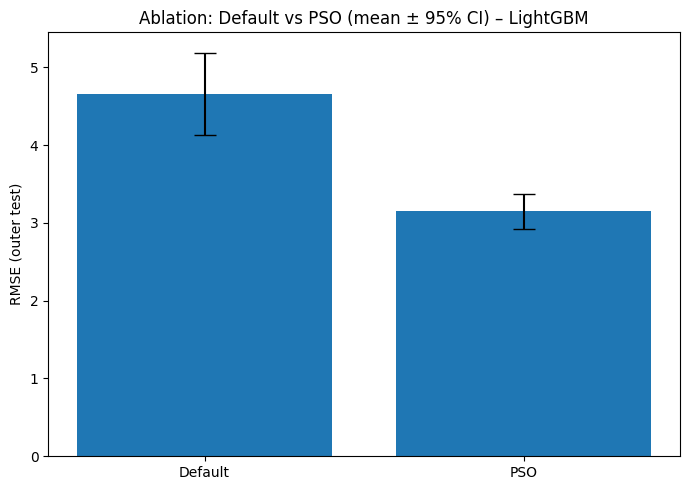

[LightGBM] [Warning] feature_fraction is set=0.672399, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.672399
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.672399, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.672399
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000054 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 180
[LightGBM] [Info] Number of data points in the train set: 410, number of used features: 8
[LightGBM] [Warning] feature_fraction is set=0.672399, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.672399
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 31.767195
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

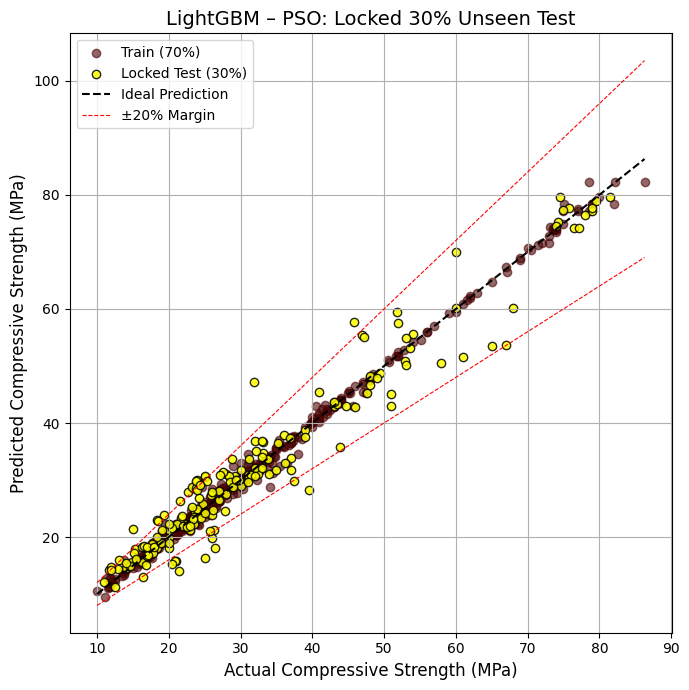


All results saved in: lgb_pso_grouped_nestedcv_outputs_noscale


In [ ]:
#!pip -q install lightgbm pyswarm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from pyswarm import pso
from scipy.stats import bootstrap
import lightgbm as lgb

OUT_DIR = "lgb_pso_grouped_nestedcv_outputs_noscale"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED  = 42

PSO_CONFIG = dict(swarmsize=20, maxiter=25, omega=0.7, phip=1.5, phig=1.5)

LB = [10, 3, 0.01, 50, 0.5, 5]
UB = [80, 30, 0.3, 500, 1.0, 50]

df = pd.read_excel("Coconut fiber data.xlsx")
X = df.drop(columns=["Compressive Strength"])
y = df["Compressive Strength"]
groups = df["Source"].reset_index(drop=True) if "Source" in df.columns else pd.Series(np.arange(len(df)))

gss = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_all, X_test_locked = X.iloc[train_idx], X.iloc[test_idx]
y_train_all, y_test_locked = y.iloc[train_idx], y.iloc[test_idx]
groups_train_all, groups_test_locked = groups.iloc[train_idx], groups.iloc[test_idx]

def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    medae = np.median(np.abs(y_true - y_pred))
    return r2, rmse, mae, mape, medae

def decode_lgb_params(params):
    num_leaves = int(round(params[0]))
    max_depth = int(round(params[1]))
    learning_rate = float(params[2])
    n_estimators = int(round(params[3]))
    feature_fraction = float(params[4])
    min_child_samples = int(round(params[5]))

    return dict(
        boosting_type='gbdt',
        objective='regression',
        metric='rmse',
        num_leaves=num_leaves,
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        feature_fraction=feature_fraction,
        min_child_samples=min_child_samples,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

def lgb_inner_rmse(params, X_tr, y_tr, g_tr):
    hp = decode_lgb_params(params)
    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []
    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        X_t, X_v = X_tr.iloc[tr_i], X_tr.iloc[val_i]
        y_t, y_v = y_tr.iloc[tr_i], y_tr.iloc[val_i]
        model = lgb.LGBMRegressor(**hp)
        model.fit(
            X_t, y_t,
            eval_set=[(X_v, y_v)],
            eval_metric="rmse",
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(0)
            ]
        )
        preds = model.predict(X_v)
        rmses.append(np.sqrt(mean_squared_error(y_v, preds)))
    return np.mean(rmses)

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)
oof_rows, tr_rows, fold_metrics, per_fold_params = [], [], [], []
rmse_default_per_fold, rmse_pso_per_fold = [], []

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_train_all, y_train_all, groups_train_all), 1):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")
    X_tr, X_te = X_train_all.iloc[tr_idx], X_train_all.iloc[te_idx]
    y_tr, y_te = y_train_all.iloc[tr_idx], y_train_all.iloc[te_idx]
    g_tr, g_te = groups_train_all.iloc[tr_idx], groups_train_all.iloc[te_idx]

    t0 = time.time()
    obj = lambda p: lgb_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)
    t_min = (time.time() - t0) / 60.0
    hp = decode_lgb_params(opt_params)
    print(f"Fold {fold} PSO done in {t_min:.2f} min → {hp}")

    per_fold_params.append({"fold": fold, "best_params": hp})

    # --- Train with best params (full fold, no early stop) ---
    model = lgb.LGBMRegressor(**hp)
    model.fit(X_tr, y_tr)
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    tr_rows.append(pd.DataFrame({"fold": fold, "role": "train",
                                 "y_true": y_tr.values, "y_pred": y_tr_pred}))
    oof_rows.append(pd.DataFrame({"fold": fold, "role": "test",
                                  "y_true": y_te.values, "y_pred": y_te_pred}))

    r2t, rmset, maet, mapet, medaet = evaluate(y_te, y_te_pred)
    fold_metrics.append({"fold": fold, "r2": r2t, "rmse": rmset, "mae": maet,
                         "mape": mapet, "medae": medaet, "time_min": t_min})
    rmse_pso_per_fold.append(rmset)

    lgb_default = lgb.LGBMRegressor(random_state=RANDOM_SEED)
    lgb_default.fit(X_tr, y_tr)
    y_te_def = lgb_default.predict(X_te)
    rmse_default_per_fold.append(np.sqrt(mean_squared_error(y_te, y_te_def)))

oof_df = pd.concat(oof_rows, ignore_index=True)
tr_df  = pd.concat(tr_rows,  ignore_index=True)
oof_df.to_csv(f"{OUT_DIR}/oof_predictions_test.csv", index=False)
tr_df.to_csv (f"{OUT_DIR}/train_predictions_per_fold.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
ci95 = bootstrap((fold_df["rmse"].values,), np.mean, confidence_level=0.95, random_state=RANDOM_SEED)
fold_df["rmse_mean_ci95"] = f"{fold_df.rmse.mean():.3f} ± {(ci95.confidence_interval[1]-fold_df.rmse.mean()):.3f}"
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

with open(f"{OUT_DIR}/best_params_per_fold.json", "w") as f:
    json.dump(per_fold_params, f, indent=2)

TUNED_KEYS = ["num_leaves","max_depth","learning_rate","n_estimators","feature_fraction","min_child_samples"]

bp_df = pd.DataFrame([
    {"fold": d["fold"], **{k: d["best_params"][k] for k in TUNED_KEYS}}
    for d in per_fold_params
])
bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold_table.csv", index=False)

bp_summary = bp_df.drop(columns=["fold"]).agg(["mean","std"]).round(6)
bp_summary.to_csv(f"{OUT_DIR}/best_params_mean_std.csv")

def ci95_width(values):
    b = bootstrap((np.array(values),), np.mean, confidence_level=0.95, random_state=RANDOM_SEED)
    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)
err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

plt.figure(figsize=(7,5))
plt.bar(["Default", "PSO"], [rmse_def_mean, rmse_pso_mean],
        yerr=[err_def, err_pso], capsize=8)
plt.ylabel("RMSE (outer test)")
plt.title("Ablation: Default vs PSO (mean ± 95% CI) – LightGBM")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600)
plt.show()

best_params_avg = bp_summary.loc["mean"].to_dict()
final_hp = decode_lgb_params([
    best_params_avg["num_leaves"],
    best_params_avg["max_depth"],
    best_params_avg["learning_rate"],
    best_params_avg["n_estimators"],
    best_params_avg["feature_fraction"],
    best_params_avg["min_child_samples"]
])

final_model = lgb.LGBMRegressor(**final_hp)
final_model.fit(
    X_train_all, y_train_all,
    eval_set=[(X_test_locked, y_test_locked)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(0)
    ]
)
y_train_pred_final = final_model.predict(X_train_all)
y_test_pred_final  = final_model.predict(X_test_locked)

r2_t, rmse_t, mae_t, mape_t, medae_t = evaluate(y_test_locked, y_test_pred_final)
print("\nFinal Locked Test Metrics (unseen 30%):")
print(f"R²={r2_t:.4f}, RMSE={rmse_t:.3f}, MAE={mae_t:.3f}, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f}")
print("Final averaged LGB params:", final_hp)

pd.DataFrame({"y_true": y_test_locked, "y_pred": y_test_pred_final}).to_csv(
    f"{OUT_DIR}/locked_test_predictions.csv", index=False
)

plt.figure(figsize=(7,7))
plt.scatter(y_train_all, y_train_pred_final, color='#4A0404', alpha=0.6, label='Train (70%)')
plt.scatter(y_test_locked, y_test_pred_final, color='yellow', edgecolor='k', alpha=0.85, label='Locked Test (30%)')

min_val = min(y.min(), y_test_pred_final.min())
max_val = max(y.max(), y_test_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal Prediction')
plt.plot([min_val, max_val], [min_val*1.2, max_val*1.2], 'r--', lw=0.8, label='±20% Margin')
plt.plot([min_val, max_val], [min_val*0.8, max_val*0.8], 'r--', lw=0.8)

plt.xlabel("Actual Compressive Strength (MPa)", fontsize=12)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=12)
plt.title("LightGBM – PSO: Locked 30% Unseen Test", fontsize=14)
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/LGB_PSO_locked_test_regression.png", dpi=600)
plt.show()

print("\nAll results saved in:", OUT_DIR)

Extreme Gradient Boosting


=== Outer Fold 1/5 ===
Stopping search: maximum iterations reached --> 25
Fold 1 PSO done in 5.34 min → {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 4, 'learning_rate': 0.10359451439992562, 'n_estimators': 500, 'subsample': 0.9024712446882005, 'colsample_bytree': 0.5860942977298912, 'min_child_weight': 4, 'random_state': 42, 'n_jobs': -1}

=== Outer Fold 2/5 ===
Stopping search: maximum iterations reached --> 25
Fold 2 PSO done in 4.00 min → {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 5, 'learning_rate': 0.0968755327066743, 'n_estimators': 434, 'subsample': 0.610182060235181, 'colsample_bytree': 0.7776427773134725, 'min_child_weight': 1, 'random_state': 42, 'n_jobs': -1}

=== Outer Fold 3/5 ===
Stopping search: maximum iterations reached --> 25
Fold 3 PSO done in 4.24 min → {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 4, 'learning_rate': 0.1385582579761646, 'n_estimators': 500, 'subsample': 0.5443002172755071,

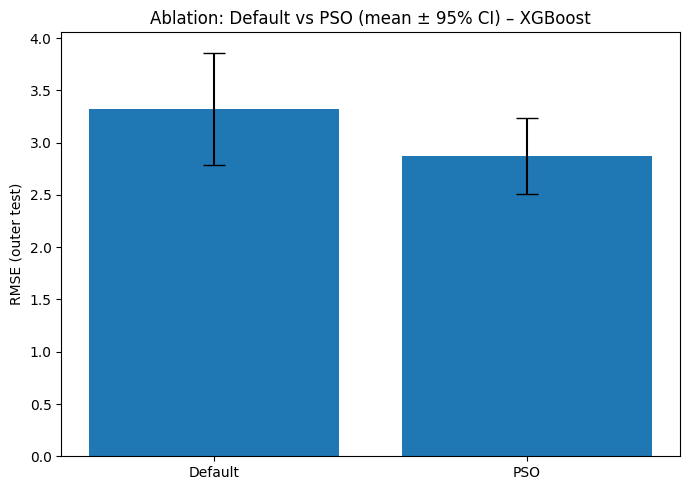


Final Locked Test Metrics:
R²=0.9501, RMSE=3.830, MAE=2.578, MAPE=8.56%, MedAE=1.505
Final averaged params: {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 6, 'learning_rate': 0.15029952091079157, 'n_estimators': 438, 'subsample': 0.7134969688114298, 'colsample_bytree': 0.6316935627227379, 'min_child_weight': 3, 'random_state': 42, 'n_jobs': -1}


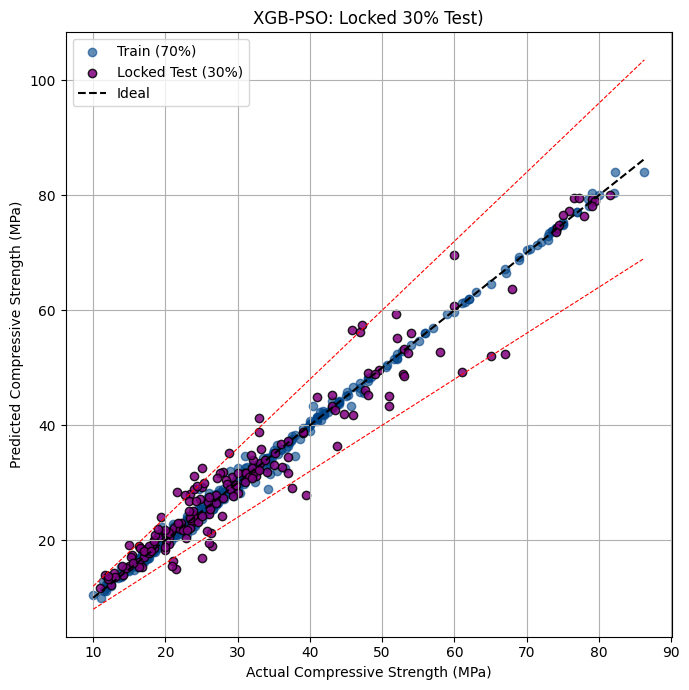


All results saved in: xgb_pso


In [ ]:
!pip -q install xgboost pyswarm openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time, warnings
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from pyswarm import pso
from scipy.stats import bootstrap
import xgboost as xgb

warnings.filterwarnings("ignore")

OUT_DIR = "xgb_pso"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED  = 42

PSO_CONFIG = dict(swarmsize=20, maxiter=25, omega=0.7, phip=1.5, phig=1.5)
LB = [3, 0.01, 50, 0.5, 0.5, 1]
UB = [15, 0.30, 500, 1.0, 1.0, 10]

df = pd.read_excel("Coconut fiber data.xlsx")
X = df.drop(columns=["Compressive Strength"])
y = df["Compressive Strength"]
groups = df["Source"].reset_index(drop=True) if "Source" in df.columns else pd.Series(np.arange(len(df)))

gss = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_all, X_test_locked = X.iloc[train_idx], X.iloc[test_idx]
y_train_all, y_test_locked = y.iloc[train_idx], y.iloc[test_idx]
groups_train_all, groups_test_locked = groups.iloc[train_idx], groups.iloc[test_idx]

def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    medae = np.median(np.abs(y_true - y_pred))
    return r2, rmse, mae, mape, medae

def decode_xgb_params(params):
    max_depth        = int(round(params[0]))
    learning_rate    = float(params[1])
    n_estimators     = int(round(params[2]))
    subsample        = float(params[3])
    colsample_bytree = float(params[4])
    min_child_weight = int(round(params[5]))
    return dict(
        objective='reg:squarederror',
        eval_metric='rmse',
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

def xgb_inner_rmse(params, X_tr, y_tr, g_tr):
    hp = decode_xgb_params(params)
    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []
    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        X_t, X_v = X_tr.iloc[tr_i], X_tr.iloc[val_i]
        y_t, y_v = y_tr.iloc[tr_i], y_tr.iloc[val_i]
        model = xgb.XGBRegressor(**hp)
        model.fit(X_t, y_t)
        preds = model.predict(X_v)
        rmses.append(np.sqrt(mean_squared_error(y_v, preds)))
    return np.mean(rmses)

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)
oof_rows, tr_rows, fold_metrics, per_fold_params = [], [], [], []
rmse_default_per_fold, rmse_pso_per_fold = [], []

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_train_all, y_train_all, groups_train_all), 1):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")
    X_tr, X_te = X_train_all.iloc[tr_idx], X_train_all.iloc[te_idx]
    y_tr, y_te = y_train_all.iloc[tr_idx], y_train_all.iloc[te_idx]
    g_tr, g_te = groups_train_all.iloc[tr_idx], groups_train_all.iloc[te_idx]

    t0 = time.time()
    obj = lambda p: xgb_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)
    t_min = (time.time() - t0) / 60.0
    hp = decode_xgb_params(opt_params)
    print(f"Fold {fold} PSO done in {t_min:.2f} min → {hp}")

    per_fold_params.append({"fold": fold, "best_params": hp})

    model = xgb.XGBRegressor(**hp)
    model.fit(X_tr, y_tr)
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    tr_rows.append(pd.DataFrame({"fold": fold, "role": "train", "y_true": y_tr, "y_pred": y_tr_pred}))
    oof_rows.append(pd.DataFrame({"fold": fold, "role": "test", "y_true": y_te, "y_pred": y_te_pred}))

    r2t, rmset, maet, mapet, medaet = evaluate(y_te, y_te_pred)
    fold_metrics.append({"fold": fold, "r2": r2t, "rmse": rmset, "mae": maet, "mape": mapet, "medae": medaet, "time_min": t_min})
    rmse_pso_per_fold.append(rmset)

    xgb_def = xgb.XGBRegressor(random_state=RANDOM_SEED)
    xgb_def.fit(X_tr, y_tr)
    y_def = xgb_def.predict(X_te)
    rmse_default_per_fold.append(np.sqrt(mean_squared_error(y_te, y_def)))

oof_df = pd.concat(oof_rows)
tr_df  = pd.concat(tr_rows)
oof_df.to_csv(f"{OUT_DIR}/oof_predictions.csv", index=False)
tr_df.to_csv (f"{OUT_DIR}/train_predictions.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

bp_df = pd.DataFrame([
    {"fold": d["fold"], **d["best_params"]} for d in per_fold_params
])
bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold.csv", index=False)

# CI summary
summary_rows = []
for metric in ["r2","rmse","mae","mape","medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)
    summary_rows.append({"metric": metric.upper(), "mean": m, "std": s, "ci95": ci})
pd.DataFrame(summary_rows).to_csv(f"{OUT_DIR}/ci95_from_outer_folds.csv", index=False)

def ci95_width(values):
    b = bootstrap((np.array(values),), np.mean, confidence_level=0.95, random_state=RANDOM_SEED)
    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)
err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

plt.figure(figsize=(7,5))
plt.bar(["Default", "PSO"], [rmse_def_mean, rmse_pso_mean],
        yerr=[err_def, err_pso], capsize=8)
plt.ylabel("RMSE (outer test)")
plt.title("Ablation: Default vs PSO (mean ± 95% CI) – XGBoost")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600)
plt.show()

numeric_cols = bp_df.select_dtypes(include=[np.number]).columns
best_params_avg = bp_df[numeric_cols].mean().to_dict()
final_hp = decode_xgb_params([
    best_params_avg["max_depth"],
    best_params_avg["learning_rate"],
    best_params_avg["n_estimators"],
    best_params_avg["subsample"],
    best_params_avg["colsample_bytree"],
    best_params_avg["min_child_weight"]
])

final_model = xgb.XGBRegressor(**final_hp)
final_model.fit(X_train_all, y_train_all)
y_train_pred = final_model.predict(X_train_all)
y_test_pred  = final_model.predict(X_test_locked)

r2_t, rmse_t, mae_t, mape_t, medae_t = evaluate(y_test_locked, y_test_pred)
print(f"\nFinal Locked Test Metrics:\nR²={r2_t:.4f}, RMSE={rmse_t:.3f}, MAE={mae_t:.3f}, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f}")
print("Final averaged params:", final_hp)

pd.DataFrame({"y_true": y_test_locked, "y_pred": y_test_pred}).to_csv(f"{OUT_DIR}/locked_test_predictions.csv", index=False)

plt.figure(figsize=(7,7))
plt.scatter(y_train_all, y_train_pred, color='#004488', alpha=0.6, label='Train (70%)')
plt.scatter(y_test_locked, y_test_pred, color='purple', edgecolor='k', alpha=0.85, label='Locked Test (30%)')
min_val = min(y.min(), y_test_pred.min())
max_val = max(y.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')
plt.plot([min_val, max_val], [min_val*1.2, max_val*1.2], 'r--', lw=0.8)
plt.plot([min_val, max_val], [min_val*0.8, max_val*0.8], 'r--', lw=0.8)
plt.xlabel("Actual Compressive Strength (MPa)")
plt.ylabel("Predicted Compressive Strength (MPa)")
plt.title("XGB-PSO: Locked 30% Test)")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/XGB_PSO_locked_test_regression.png", dpi=600)
plt.show()

print("\nAll results saved in:", OUT_DIR)


**Artificial Neural Network**

  Preparing metadata (setup.py) ... done

=== Outer Fold 1/5 ===
Stopping search: maximum iterations reached --> 25
PSO done in 12.09 min → Neurons=85, LR=0.00963, Alpha=0.000076

=== Outer Fold 2/5 ===
Stopping search: maximum iterations reached --> 25
PSO done in 6.46 min → Neurons=86, LR=0.02000, Alpha=0.000183

=== Outer Fold 3/5 ===
Stopping search: maximum iterations reached --> 25
PSO done in 8.48 min → Neurons=85, LR=0.01454, Alpha=0.000163

=== Outer Fold 4/5 ===
Stopping search: maximum iterations reached --> 25
PSO done in 15.89 min → Neurons=75, LR=0.00637, Alpha=0.000763

=== Outer Fold 5/5 ===
Stopping search: maximum iterations reached --> 25
PSO done in 14.53 min → Neurons=39, LR=0.00610, Alpha=0.000744


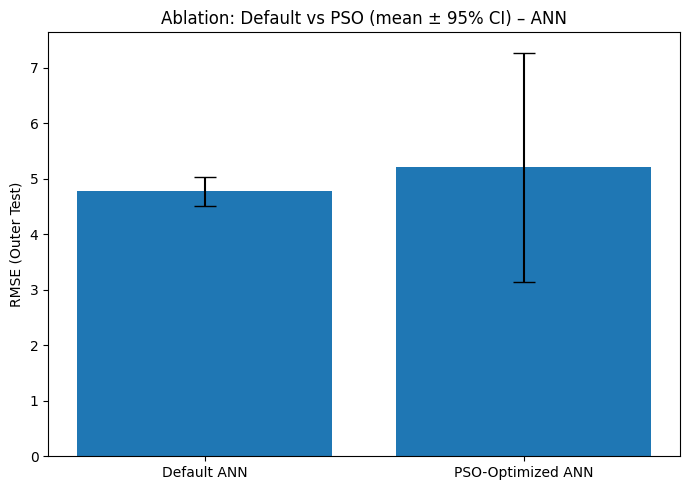


Final Locked Test Metrics:
R²=0.9176, RMSE=4.924, MAE=3.644, MAPE=12.52%, MedAE=2.637
Final averaged params: Neurons=74, LR=0.01133, Alpha=0.000386


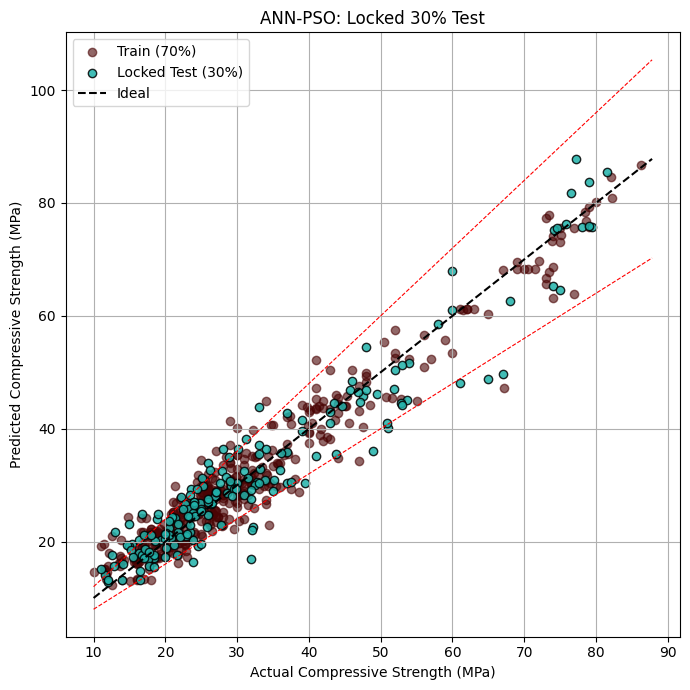


All results saved in: ann_pso


In [ ]:
#!pip -q install pyswarm openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, time, warnings
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error
from sklearn.neural_network import MLPRegressor
from pyswarm import pso
from scipy.stats import bootstrap

warnings.filterwarnings("ignore")

OUT_DIR = "ann_pso"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED  = 42

PSO_CONFIG = dict(swarmsize=20, maxiter=25, omega=0.7, phip=1.5, phig=1.5)
LB = [20, 0.001, 1e-5]
UB = [100, 0.02, 1e-3]

df = pd.read_excel("Coconut fiber data.xlsx")
X = df.drop(columns=["Compressive Strength"])
y = df["Compressive Strength"]
groups = df["Source"].reset_index(drop=True) if "Source" in df.columns else pd.Series(np.arange(len(df)))

gss = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_all, X_test_locked = X.iloc[train_idx], X.iloc[test_idx]
y_train_all, y_test_locked = y.iloc[train_idx], y.iloc[test_idx]
groups_train_all, groups_test_locked = groups.iloc[train_idx], groups.iloc[test_idx]

def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    denom = np.where(y_true == 0, np.finfo(float).eps, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    return r2, rmse, mae, mape, medae

def decode_ann_params(params):
    hidden_layer_size = int(round(params[0]))
    learning_rate_init = float(params[1])
    alpha = float(params[2])
    return hidden_layer_size, learning_rate_init, alpha

def ann_inner_rmse(params, X_tr, y_tr, g_tr):
    hidden_layer_size, learning_rate_init, alpha = decode_ann_params(params)
    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []
    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        X_t, X_v = X_tr.iloc[tr_i], X_tr.iloc[val_i]
        y_t, y_v = y_tr.iloc[tr_i], y_tr.iloc[val_i]

        scaler = StandardScaler()
        X_t_s = scaler.fit_transform(X_t)
        X_v_s = scaler.transform(X_v)

        model = MLPRegressor(
           hidden_layer_sizes=(hidden_layer_size,),
           learning_rate_init=learning_rate_init,
           alpha=alpha,
           activation='relu',
           solver='adam',
           max_iter=2000,
           random_state=RANDOM_SEED,
           early_stopping=True,
           n_iter_no_change=30,
           tol=1e-4
        )
        model.fit(X_t_s, y_t)
        preds = model.predict(X_v_s)
        rmses.append(np.sqrt(mean_squared_error(y_v, preds)))
    return np.mean(rmses)

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)
fold_metrics, per_fold_params = [], []
rmse_default_per_fold, rmse_pso_per_fold = [], []

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_train_all, y_train_all, groups_train_all), 1):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")
    X_tr, X_te = X_train_all.iloc[tr_idx], X_train_all.iloc[te_idx]
    y_tr, y_te = y_train_all.iloc[tr_idx], y_train_all.iloc[te_idx]
    g_tr, g_te = groups_train_all.iloc[tr_idx], groups_train_all.iloc[te_idx]

    t0 = time.time()
    obj = lambda p: ann_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)
    t_min = (time.time() - t0) / 60
    hidden_layer_opt, lr_opt, alpha_opt = decode_ann_params(opt_params)
    print(f"PSO done in {t_min:.2f} min → Neurons={hidden_layer_opt}, LR={lr_opt:.5f}, Alpha={alpha_opt:.6f}")

    per_fold_params.append({"fold": fold, "neurons": hidden_layer_opt, "lr": lr_opt, "alpha": alpha_opt})

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    model = MLPRegressor(
        hidden_layer_sizes=(hidden_layer_opt,),
        learning_rate_init=lr_opt,
        alpha=alpha_opt,
        activation='relu',
        solver='adam',
        max_iter=2000,
        random_state=RANDOM_SEED,
        early_stopping=True,
        n_iter_no_change=30,
        tol=1e-4
    )
    model.fit(X_tr_s, y_tr)
    y_te_pred = model.predict(X_te_s)

    r2t, rmset, maet, mapet, medaet = evaluate(y_te, y_te_pred)
    fold_metrics.append({"fold": fold, "r2": r2t, "rmse": rmset, "mae": maet, "mape": mapet, "medae": medaet, "time_min": t_min})
    rmse_pso_per_fold.append(rmset)

    ann_def = MLPRegressor(
        hidden_layer_sizes=(50,),
        learning_rate_init=0.001,
        alpha=0.0001,
        activation='relu',
        solver='adam',
        max_iter=3000,
        random_state=RANDOM_SEED
    )
    ann_def.fit(X_tr_s, y_tr)
    y_def = ann_def.predict(X_te_s)
    rmse_default_per_fold.append(np.sqrt(mean_squared_error(y_te, y_def)))
fold_df = pd.DataFrame(fold_metrics)
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)
bp_df = pd.DataFrame(per_fold_params)
bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold.csv", index=False)

summary_rows = []
for metric in ["r2","rmse","mae","mape","medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)
    summary_rows.append({"metric": metric.upper(), "mean": m, "std": s, "ci95": ci})
pd.DataFrame(summary_rows).to_csv(f"{OUT_DIR}/ci95_from_outer_folds.csv", index=False)

def ci95_width(values):
    b = bootstrap((np.array(values),), np.mean, confidence_level=0.95, random_state=RANDOM_SEED)
    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)
err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

plt.figure(figsize=(7,5))
plt.bar(["Default ANN", "PSO-Optimized ANN"], [rmse_def_mean, rmse_pso_mean],
        yerr=[err_def, err_pso], capsize=8)
plt.ylabel("RMSE (Outer Test)")
plt.title("Ablation: Default vs PSO (mean ± 95% CI) – ANN")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600)
plt.show()

best_params_avg = bp_df[["neurons","lr","alpha"]].mean().to_dict()
hidden_layer_final = int(round(best_params_avg["neurons"]))
lr_final = float(best_params_avg["lr"])
alpha_final = float(best_params_avg["alpha"])

scaler_final = StandardScaler()
X_train_s = scaler_final.fit_transform(X_train_all)
X_test_s  = scaler_final.transform(X_test_locked)

final_model = MLPRegressor(
    hidden_layer_sizes=(hidden_layer_final,),
    learning_rate_init=lr_final,
    alpha=alpha_final,
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=RANDOM_SEED,
    early_stopping=True,
    n_iter_no_change=30,
    tol=1e-4
)
final_model.fit(X_train_s, y_train_all)
y_train_pred = final_model.predict(X_train_s)
y_test_pred  = final_model.predict(X_test_s)

r2_t, rmse_t, mae_t, mape_t, medae_t = evaluate(y_test_locked, y_test_pred)
print(f"\nFinal Locked Test Metrics:\nR²={r2_t:.4f}, RMSE={rmse_t:.3f}, MAE={mae_t:.3f}, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f}")
print(f"Final averaged params: Neurons={hidden_layer_final}, LR={lr_final:.5f}, Alpha={alpha_final:.6f}")

pd.DataFrame({"y_true": y_test_locked, "y_pred": y_test_pred}).to_csv(f"{OUT_DIR}/locked_test_predictions.csv", index=False)

plt.figure(figsize=(7,7))
plt.scatter(y_train_all, y_train_pred, color='#4A0404', alpha=0.6, label='Train (70%)')
plt.scatter(y_test_locked, y_test_pred, color='lightseagreen', edgecolor='k', alpha=0.85, label='Locked Test (30%)')
min_val = min(y.min(), y_test_pred.min())
max_val = max(y.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')
plt.plot([min_val, max_val], [min_val*1.2, max_val*1.2], 'r--', lw=0.8)
plt.plot([min_val, max_val], [min_val*0.8, max_val*0.8], 'r--', lw=0.8)
plt.xlabel("Actual Compressive Strength (MPa)")
plt.ylabel("Predicted Compressive Strength (MPa)")
plt.title("ANN-PSO: Locked 30% Test")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ANN_PSO_locked_test_regression.png", dpi=600)
plt.show()

print("\nAll results saved in:", OUT_DIR)


**Error Plots Code**

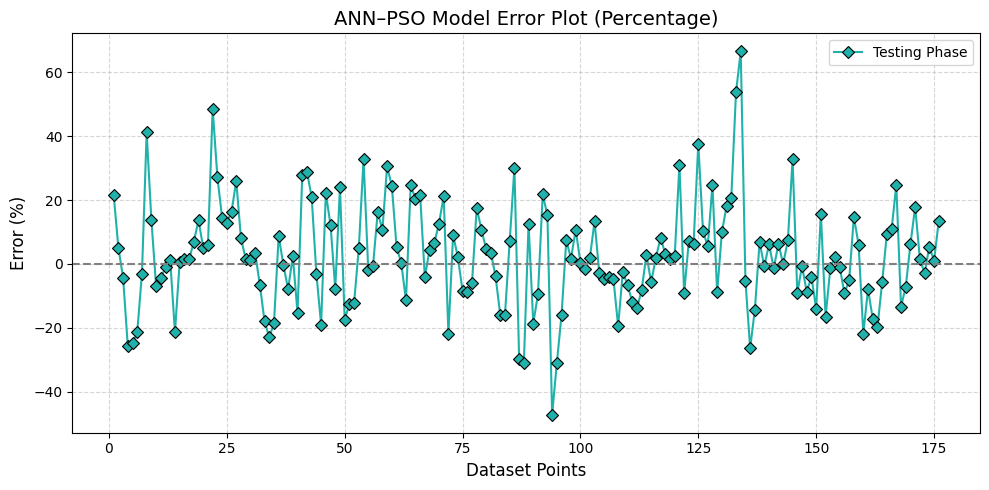

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = "/content/ANN Locked Test Predictions.xlsx"
test_df = pd.read_excel(file_path)

test_df['Error (%)'] = ((test_df['y_pred'] - test_df['y_true']) / test_df['y_true']) * 100

test_df['Sample'] = np.arange(1, len(test_df) + 1)

plt.figure(figsize=(10, 5))
plt.plot(test_df['Sample'], test_df['Error (%)'], 'D-',
         color='lightseagreen', label='Testing Phase',
         markersize=6, markeredgecolor='black', markeredgewidth=0.8)

plt.axhline(y=0, color='gray', linestyle='--')
plt.title("ANN–PSO Model Error Plot (Percentage)", fontsize=14)
plt.xlabel("Dataset Points", fontsize=12)
plt.ylabel("Error (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("ANN_PSO_Test_Error_Percentage_Plot.png", dpi=600)
plt.show()


**SHAP Analysis**

In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
OUT_DIR = "xgb_pso_shap_final"
os.makedirs(OUT_DIR, exist_ok=True)

DF_PATH = "Coconut fiber data.xlsx"
TARGET_COL = "Compressive Strength (MPa)"
df = pd.read_excel(DF_PATH)
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

train_idx = np.load("train_idx.npy")
test_idx  = np.load("test_idx.npy")
X_train_all = X.loc[train_idx]
X_test_locked = X.loc[test_idx]
y_train_all = y.loc[train_idx]
y_test_locked = y.loc[test_idx]

final_hp = dict(
    objective="reg:squarederror",
    eval_metric="rmse",
    max_depth=6,
    learning_rate=0.15029952891079157,
    n_estimators=438,
    subsample=0.7134969688114298,
    colsample_bytree=0.6316935627272379,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

final_model = xgb.XGBRegressor(**final_hp)
final_model.fit(X_train_all, y_train_all)

def eval_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    medae = float(np.median(np.abs(y_true - y_pred)))
    return r2, rmse, mae, mape, medae

y_test_pred = final_model.predict(X_test_locked)
r2_t, rmse_t, mae_t, mape_t, medae_t = eval_metrics(y_test_locked, y_test_pred)
print(f"\n=== Locked Test (exact split) ===\nR²={r2_t:.4f}, RMSE={rmse_t:.3f} MPa, "
      f"MAE={mae_t:.3f} MPa, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f} MPa")

explainer = shap.Explainer(final_model, X_train_all)
shap_test = explainer(X_test_locked)

np.savetxt(f"{OUT_DIR}/shap_base_values.csv",
           np.atleast_1d(shap_test.base_values), delimiter=",", header="base_value", comments="")
pd.DataFrame(shap_test.values, columns=shap_test.feature_names).to_csv(
    f"{OUT_DIR}/shap_values_test.csv", index=False
)
pd.DataFrame({"y_true": y_test_locked.values, "y_pred": y_test_pred}).to_csv(
    f"{OUT_DIR}/shap_test_targets_preds.csv", index=False
)

#Beeswarm
fig = plt.figure()
shap.plots.beeswarm(shap_test, max_display=10, color=plt.cm.copper, show=False)
plt.title("SHAP Summary (Locked Test) – Contributions in MPa", fontsize=12)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/shap_beeswarm_test.png", dpi=600, bbox_inches="tight")
plt.close(fig)

#Mean SHAP bar
mean_abs = shap_test.abs.mean(0).values
feat_names = np.array(shap_test.feature_names)
order = np.argsort(mean_abs)
custom_color = '#8B5A2B'
plt.figure(figsize=(8, 6))
plt.barh(range(len(order)), mean_abs[order], color=custom_color)
plt.yticks(range(len(order)), feat_names[order])
plt.xlabel("Mean |SHAP| (MPa)", fontsize=12)
plt.title("Global Feature Importance (XGB, Test SHAP in MPa)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_importance_bar_test.png", dpi=600, bbox_inches="tight")
plt.close()

pd.DataFrame({
    "feature": feat_names[order],
    "mean_abs_shap_MPa": mean_abs[order]
}).to_csv(f"{OUT_DIR}/shap_importance_mean_abs_test.csv", index=False)

#Dependence plots
TOP_K = min(8, len(feat_names))
top_feats = feat_names[np.argsort(mean_abs)[-TOP_K:]][::-1]

for feat in top_feats:
    shap.plots.scatter(
        shap_test[:, feat],
        color=shap_test[:, feat],
        cmap=plt.cm.copper,
        show=False
    )
    plt.title(f"SHAP Dependence: {feat} (MPa contribution)", fontsize=11)
    plt.tight_layout()
    plt.gcf().savefig(
        f"{OUT_DIR}/shap_dependence_test_{re.sub(r'[^A-Za-z0-9._-]+','_', feat)}.png",
        dpi=600, bbox_inches="tight"
    )
    plt.close(plt.gcf())


=== Locked Test (exact split) ===
R²=0.9501, RMSE=3.830 MPa, MAE=2.578 MPa, MAPE=8.56%, MedAE=1.505 MPa


In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
OUT_DIR = "xgb_pso_shap_final"
os.makedirs(OUT_DIR, exist_ok=True)

DF_PATH = "Coconut fiber data.xlsx"
TARGET_COL = "Compressive Strength (MPa)"
df = pd.read_excel(DF_PATH)
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

#Load PSO Indices
train_idx = np.load("train_idx.npy")
test_idx  = np.load("test_idx.npy")
X_train_all = X.loc[train_idx]
X_test_locked = X.loc[test_idx]
y_train_all = y.loc[train_idx]
y_test_locked = y.loc[test_idx]

final_hp = dict(
    objective="reg:squarederror",
    eval_metric="rmse",
    max_depth=6,
    learning_rate=0.15029952891079157,
    n_estimators=438,
    subsample=0.7134969688114298,
    colsample_bytree=0.6316935627272379,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

final_model = xgb.XGBRegressor(**final_hp)
final_model.fit(X_train_all, y_train_all)

def eval_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    medae = float(np.median(np.abs(y_true - y_pred)))
    return r2, rmse, mae, mape, medae

y_test_pred = final_model.predict(X_test_locked)
r2_t, rmse_t, mae_t, mape_t, medae_t = eval_metrics(y_test_locked, y_test_pred)
print(f"\n=== Locked Test (exact split) ===\nR²={r2_t:.4f}, RMSE={rmse_t:.3f} MPa, "
      f"MAE={mae_t:.3f} MPa, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f} MPa")

pd.DataFrame({"y_true": y_test_locked.values, "y_pred": y_test_pred}).to_csv(
    f"{OUT_DIR}/locked_test_predictions.csv", index=False
)

explainer = shap.Explainer(final_model, X_train_all)
shap_test = explainer(X_test_locked)

N_TEST = len(X_test_locked)
SHAP_YLIM = (-16, 16)

np.savetxt(
    f"{OUT_DIR}/shap_base_values.csv",
    np.atleast_1d(shap_test.base_values),
    delimiter=",",
    header="base_value",
    comments=""
)
pd.DataFrame(shap_test.values, columns=shap_test.feature_names).to_csv(
    f"{OUT_DIR}/shap_values_test.csv", index=False
)
pd.DataFrame({"y_true": y_test_locked.values, "y_pred": y_test_pred}).to_csv(
    f"{OUT_DIR}/shap_test_targets_preds.csv", index=False
)

#Beeswarm
shap.plots.beeswarm(shap_test, max_display=10, color=plt.cm.copper, show=False)
plt.xlabel("SHAP value (MPa)")                           # unit on x-axis
plt.title(f"SHAP Summary (Locked Test, n={N_TEST})", fontsize=12)
plt.tight_layout()
plt.gcf().savefig(f"{OUT_DIR}/shap_beeswarm_test.png", dpi=600, bbox_inches="tight")
plt.close(plt.gcf())

#Mean SHAP bar
mean_abs = shap_test.abs.mean(0).values
feat_names = np.array(shap_test.feature_names)
order = np.argsort(mean_abs)

custom_color = '#8B5A2B'
plt.figure(figsize=(8, 6))
plt.barh(range(len(order)), mean_abs[order], color=custom_color)
plt.yticks(range(len(order)), feat_names[order])
plt.xlabel("Mean |SHAP| (MPa)", fontsize=12)
plt.title("Global Feature Importance (XGB, Test SHAP in MPa)", fontsize=12)
plt.tight_layout()
plt.gcf().savefig(f"{OUT_DIR}/shap_importance_bar_test.png", dpi=600, bbox_inches="tight")
plt.close(plt.gcf())

pd.DataFrame({
    "feature": feat_names[order],
    "mean_abs_shap_MPa": mean_abs[order]
}).to_csv(f"{OUT_DIR}/shap_importance_mean_abs_test.csv", index=False)

#Dependence plots
TOP_K = min(8, len(feat_names))
top_feats = feat_names[np.argsort(mean_abs)[-TOP_K:]][::-1]

for feat in top_feats:
    shap.plots.scatter(
        shap_test[:, feat],
        color=shap_test[:, feat],
        cmap=plt.cm.copper,
        show=False
    )
    plt.ylim(SHAP_YLIM)
    plt.ylabel("SHAP value (MPa)")
    plt.title(f"SHAP Dependence: {feat} (MPa contribution, n={N_TEST})", fontsize=11)

    fig = plt.gcf()
    axes = fig.get_axes()
    if len(axes) > 1:
        cb_ax = axes[-1]
        cb_ax.set_ylabel("")
        for txt in cb_ax.texts:
            txt.set_visible(False)

    plt.tight_layout()
    fig.savefig(
        f"{OUT_DIR}/shap_dependence_test_{re.sub(r'[^A-Za-z0-9._-]+','_', feat)}.png",
        dpi=600, bbox_inches="tight"
    )
    plt.close(fig)

#Interaction dependence plots
pairs = [
    ("RCA (%)", "Water (kg/m³)"),
    ("Fiber (%)", "Cement (kg/m³)"),
    ("Cement (kg/m³)", "Water (kg/m³)"),
    ("RCA (%)", "NCA (kg/m³)")
]

for main_feat, interact_feat in pairs:
    if (main_feat in X_test_locked.columns) and (interact_feat in X_test_locked.columns):
        shap.plots.scatter(
            shap_test[:, main_feat],
            color=shap_test[:, interact_feat],
            cmap=plt.cm.copper,
            show=False
        )
        plt.ylim(SHAP_YLIM)
        plt.ylabel("SHAP value (MPa)")
        plt.title(f"SHAP Interaction: {main_feat} × {interact_feat} (MPa, n={N_TEST})", fontsize=11)

        fig = plt.gcf()
        axes = fig.get_axes()
        if len(axes) > 1:
            cb_ax = axes[-1]
            cb_ax.set_ylabel("")
            for txt in cb_ax.texts:
                txt.set_visible(False)
            cb_ax.set_ylabel(interact_feat)

        plt.tight_layout()
        fig.savefig(
            f"{OUT_DIR}/shap_interaction_{re.sub(r'[^A-Za-z0-9._-]+','_', main_feat)}"
            f"_X_{re.sub(r'[^A-Za-z0-9._-]+','_', interact_feat)}.png",
            dpi=600, bbox_inches="tight"
        )
        plt.close(fig)

print("\n[SHAP] Done. Outputs saved in:", OUT_DIR)



=== Locked Test (exact split) ===
R²=0.9501, RMSE=3.830 MPa, MAE=2.578 MPa, MAPE=8.56%, MedAE=1.505 MPa

[SHAP] Done. Outputs saved in: xgb_pso_shap_final


**SHAP Rank Stability**

In [ ]:
#!pip install pyswarm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time, warnings, re
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from pyswarm import pso
from scipy.stats import bootstrap, kendalltau
import shap
import xgboost as xgb

warnings.filterwarnings("ignore")

OUT_DIR = "xgb_pso_cv_stability"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED  = 42

PSO_CONFIG = dict(swarmsize=20, maxiter=25, omega=0.7, phip=1.5, phig=1.5)
LB = [3, 0.01, 50, 0.5, 0.5, 1]
UB = [15, 0.30, 500, 1.0, 1.0, 10]

df = pd.read_excel("Coconut fiber data.xlsx")
TARGET_COL = "Compressive Strength"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]
groups = df["Source"].reset_index(drop=True) if "Source" in df.columns else pd.Series(np.arange(len(df)))

gss = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_all, X_test_locked = X.iloc[train_idx], X.iloc[test_idx]
y_train_all, y_test_locked = y.iloc[train_idx], y.iloc[test_idx]
groups_train_all, groups_test_locked = groups.iloc[train_idx], groups.iloc[test_idx]

np.save("train_idx.npy", X_train_all.index.values)
np.save("test_idx.npy",  X_test_locked.index.values)

def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    medae = np.median(np.abs(y_true - y_pred))
    return r2, rmse, mae, mape, medae

def decode_xgb_params(params):
    max_depth        = int(round(params[0]))
    learning_rate    = float(params[1])
    n_estimators     = int(round(params[2]))
    subsample        = float(params[3])
    colsample_bytree = float(params[4])
    min_child_weight = int(round(params[5]))
    return dict(
        objective='reg:squarederror',
        eval_metric='rmse',
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0
    )

def xgb_inner_rmse(params, X_tr, y_tr, g_tr):
    hp = decode_xgb_params(params)
    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []
    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        X_t, X_v = X_tr.iloc[tr_i], X_tr.iloc[val_i]
        y_t, y_v = y_tr.iloc[tr_i], y_tr.iloc[val_i]
        model = xgb.XGBRegressor(**hp)
        model.fit(X_t, y_t)
        preds = model.predict(X_v)
        rmses.append(np.sqrt(mean_squared_error(y_v, preds)))
    return np.mean(rmses)

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)
oof_rows, tr_rows, fold_metrics, per_fold_params = [], [], [], []
rmse_default_per_fold, rmse_pso_per_fold = [], []

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_train_all, y_train_all, groups_train_all), 1):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")
    X_tr, X_te = X_train_all.iloc[tr_idx], X_train_all.iloc[te_idx]
    y_tr, y_te = y_train_all.iloc[tr_idx], y_train_all.iloc[te_idx]
    g_tr, g_te = groups_train_all.iloc[tr_idx], groups_train_all.iloc[te_idx]

    t0 = time.time()
    obj = lambda p: xgb_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)
    t_min = (time.time() - t0) / 60.0
    hp = decode_xgb_params(opt_params)
    print(f"Fold {fold} PSO done in {t_min:.2f} min → {hp}")

    per_fold_params.append({"fold": fold, **hp})

    model = xgb.XGBRegressor(**hp)
    model.fit(X_tr, y_tr)
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    tr_rows.append(pd.DataFrame({"fold": fold, "role": "train", "y_true": y_tr, "y_pred": y_tr_pred}))
    oof_rows.append(pd.DataFrame({"fold": fold, "role": "test",  "y_true": y_te, "y_pred": y_te_pred}))

    r2t, rmset, maet, mapet, medaet = evaluate(y_te, y_te_pred)
    fold_metrics.append({
        "fold": fold, "r2": r2t, "rmse": rmset, "mae": maet,
        "mape": mapet, "medae": medaet, "time_min": t_min
    })
    rmse_pso_per_fold.append(rmset)

    xgb_def = xgb.XGBRegressor(random_state=RANDOM_SEED)
    xgb_def.fit(X_tr, y_tr)
    y_def = xgb_def.predict(X_te)
    rmse_default_per_fold.append(np.sqrt(mean_squared_error(y_te, y_def)))

    try:
        expl_fold = shap.Explainer(model, X_tr)
    except Exception:
        expl_fold = shap.TreeExplainer(model, X_tr)
    shap_fold = expl_fold(X_te)

    mean_abs_fold = shap_fold.abs.mean(0).values
    feat_names_fold = np.array(shap_fold.feature_names)

    fold_shap_df = pd.DataFrame({
        "fold": fold,
        "feature": feat_names_fold,
        "mean_abs_shap": mean_abs_fold
    })
    fold_shap_df.to_csv(f"{OUT_DIR}/fold_{fold}_mean_abs_shap.csv", index=False)

oof_df = pd.concat(oof_rows)
tr_df  = pd.concat(tr_rows)
oof_df.to_csv(f"{OUT_DIR}/oof_predictions.csv", index=False)
tr_df.to_csv (f"{OUT_DIR}/train_predictions.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

bp_df = pd.DataFrame(per_fold_params)
bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold.csv", index=False)

summary_rows = []
for metric in ["r2","rmse","mae","mape","medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)
    summary_rows.append({"metric": metric.upper(), "mean": m, "std": s, "ci95": ci})
pd.DataFrame(summary_rows).to_csv(f"{OUT_DIR}/ci95_from_outer_folds.csv", index=False)

def ci95_width(values):
    b = bootstrap((np.array(values),), np.mean, confidence_level=0.95, random_state=RANDOM_SEED)
    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)
err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

plt.figure(figsize=(7,5))
plt.bar(["Default", "PSO"], [rmse_def_mean, rmse_pso_mean],
        yerr=[err_def, err_pso], capsize=8)
plt.ylabel("RMSE (outer test)")
plt.title("Ablation: Default vs PSO (mean ± 95% CI) – XGBoost")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600)
plt.close()

#NEW: Rank Stability Aggregation
shap_list = []
for f in range(1, OUTER_SPLITS + 1):
    df_f = pd.read_csv(f"{OUT_DIR}/fold_{f}_mean_abs_shap.csv")
    shap_list.append(df_f)

all_shap = pd.concat(shap_list, ignore_index=True)

stab_mat = all_shap.pivot_table(index="feature", columns="fold", values="mean_abs_shap", aggfunc="mean").fillna(0.0)

rank_mat = stab_mat.rank(axis=0, ascending=False, method="average")

# Kendall's tau
tau_rows = []
folds = rank_mat.columns.tolist()
for i in range(len(folds)):
    for j in range(i+1, len(folds)):
        tau, p = kendalltau(rank_mat[folds[i]], rank_mat[folds[j]])
        tau_rows.append({"fold_i": int(folds[i]), "fold_j": int(folds[j]), "kendall_tau": float(tau), "p_value": float(p)})
tau_df = pd.DataFrame(tau_rows)
tau_df.to_csv(f"{OUT_DIR}/rank_stability_pairwise_kendall_tau.csv", index=False)

# Top-K overlap (Jaccard)
K = min(5, stab_mat.shape[0])
topk_rows = []
for i in range(len(folds)):
    Fi = set(rank_mat[folds[i]].sort_values().index[:K])
    for j in range(i+1, len(folds)):
        Fj = set(rank_mat[folds[j]].sort_values().index[:K])
        jacc = len(Fi & Fj) / len(Fi | Fj) if len(Fi | Fj) else 1.0
        topk_rows.append({"fold_i": int(folds[i]), "fold_j": int(folds[j]), "topK": K, "jaccard": float(jacc)})
pd.DataFrame(topk_rows).to_csv(f"{OUT_DIR}/rank_stability_top{K}_jaccard.csv", index=False)

# Summary (mean ± SD of ranks per feature)
rank_summary = pd.DataFrame({
    "feature": rank_mat.index,
    "mean_rank": rank_mat.mean(axis=1).values,
    "std_rank": rank_mat.std(axis=1, ddof=1).values
}).sort_values("mean_rank")
rank_summary.to_csv(f"{OUT_DIR}/rank_stability_summary.csv", index=False)

print("\n[STABILITY] Saved:")
print(" - rank_stability_pairwise_kendall_tau.csv")
print(f" - rank_stability_top{K}_jaccard.csv")
print(" - rank_stability_summary.csv")

numeric_cols = ["max_depth","learning_rate","n_estimators","subsample","colsample_bytree","min_child_weight"]
best_params_avg = bp_df[numeric_cols].mean().to_dict()

def decode_from_avg(avg_dict):
    return dict(
        objective='reg:squarederror', eval_metric='rmse',
        max_depth=int(round(avg_dict["max_depth"])),
        learning_rate=float(avg_dict["learning_rate"]),
        n_estimators=int(round(avg_dict["n_estimators"])),
        subsample=float(avg_dict["subsample"]),
        colsample_bytree=float(avg_dict["colsample_bytree"]),
        min_child_weight=int(round(avg_dict["min_child_weight"])),
        random_state=RANDOM_SEED, n_jobs=-1, verbosity=0
    )

final_hp = decode_from_avg(best_params_avg)
final_model = xgb.XGBRegressor(**final_hp)
final_model.fit(X_train_all, y_train_all)
y_test_pred  = final_model.predict(X_test_locked)

def evaluate_pack(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    medae = float(np.median(np.abs(y_true - y_pred)))
    return r2, rmse, mae, mape, medae

r2_t, rmse_t, mae_t, mape_t, medae_t = evaluate_pack(y_test_locked, y_test_pred)
print(f"\n[FINAL] Locked Test:\nR²={r2_t:.4f}, RMSE={rmse_t:.3f}, MAE={mae_t:.3f}, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f}")
pd.DataFrame({"y_true": y_test_locked.values, "y_pred": y_test_pred}).to_csv(f"{OUT_DIR}/locked_test_predictions.csv", index=False)
print("\nAll results saved in:", OUT_DIR)


  Preparing metadata (setup.py) ... done
  Created wheel for pyswarm: filename=pyswarm-0.6-py3-none-any.whl size=4463 sha256=9c7a0ea0dcecb614fe70b1bdf86ec0e0f8fb2c5f11f611ef8ed87542f5d9fa06
  Stored in directory: /root/.cache/pip/wheels/93/15/89/3970ef96abd6123028010a90f007c4e6a2bed700db0aa2d36a
Successfully built pyswarm

=== Outer Fold 1/5 ===
Stopping search: maximum iterations reached --> 25
Fold 1 PSO done in 4.01 min → {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 5, 'learning_rate': 0.07089129140052877, 'n_estimators': 481, 'subsample': 0.8576577756106006, 'colsample_bytree': 0.5, 'min_child_weight': 4, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}

=== Outer Fold 2/5 ===
Stopping search: maximum iterations reached --> 25
Fold 2 PSO done in 6.36 min → {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 13, 'learning_rate': 0.1681287719588462, 'n_estimators': 411, 'subsample': 0.5100168577955536, 'colsample_bytree': 0.7915092120363847

**SHAP Rank Stability Plots (Kendall)**

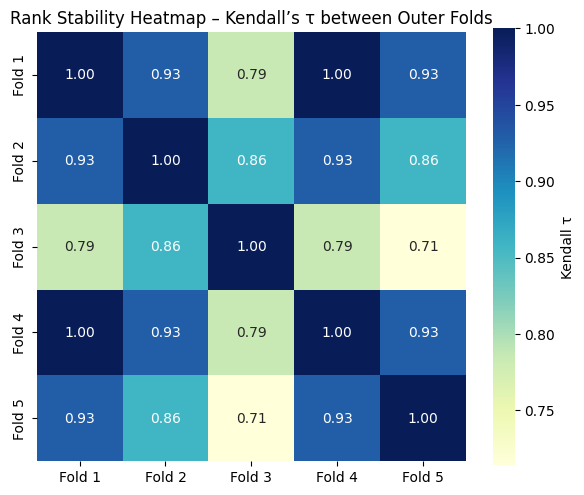

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

tau_df = pd.read_csv("rank_stability_pairwise_kendall_tau.csv")
folds = sorted(set(tau_df["fold_i"]).union(set(tau_df["fold_j"])))
n = len(folds)

tau_mat = np.ones((n, n))
for _, row in tau_df.iterrows():
    i, j = int(row["fold_i"]) - 1, int(row["fold_j"]) - 1
    tau_mat[i, j] = row["kendall_tau"]
    tau_mat[j, i] = row["kendall_tau"]

tau_matrix = pd.DataFrame(tau_mat, index=[f"Fold {i}" for i in folds], columns=[f"Fold {i}" for i in folds])

plt.figure(figsize=(6,5))
sns.heatmap(tau_matrix, annot=True, fmt=".2f", cmap="YlGnBu", square=True,
            cbar_kws={'label':"Kendall τ"})
plt.title("Rank Stability Heatmap – Kendall’s τ between Outer Folds")
plt.tight_layout()
plt.savefig("rank_stability_heatmap_tau.png", dpi=600)
plt.show()


**SHAP Rank Stability Plots (Jaccard)**

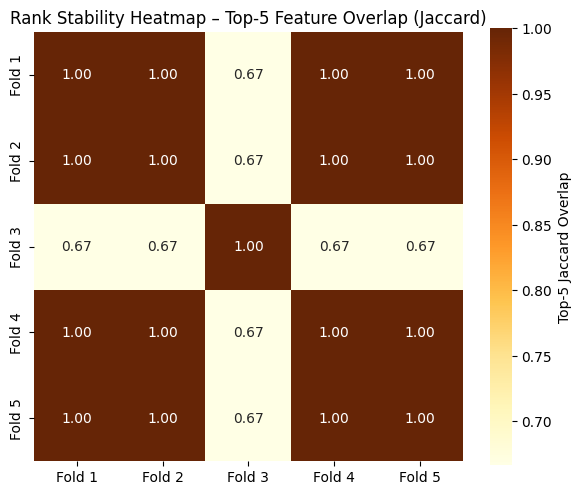

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

jac_df = pd.read_csv("rank_stability_top5_jaccard.csv")
folds = sorted(set(jac_df["fold_i"]).union(set(jac_df["fold_j"])))
n = len(folds)

jac_mat = np.ones((n, n))
for _, row in jac_df.iterrows():
    i, j = int(row["fold_i"]) - 1, int(row["fold_j"]) - 1
    jac_mat[i, j] = row["jaccard"]
    jac_mat[j, i] = row["jaccard"]

jac_matrix = pd.DataFrame(jac_mat, index=[f"Fold {i}" for i in folds], columns=[f"Fold {i}" for i in folds])

plt.figure(figsize=(6,5))
sns.heatmap(jac_matrix, annot=True, fmt=".2f", cmap="YlOrBr", square=True,
            cbar_kws={'label':"Top-5 Jaccard Overlap"})
plt.title("Rank Stability Heatmap – Top-5 Feature Overlap (Jaccard)")
plt.tight_layout()
plt.savefig("rank_stability_heatmap_jaccard.png", dpi=600)
plt.show()


**SHAP Rank Stability Plots (Summary)**

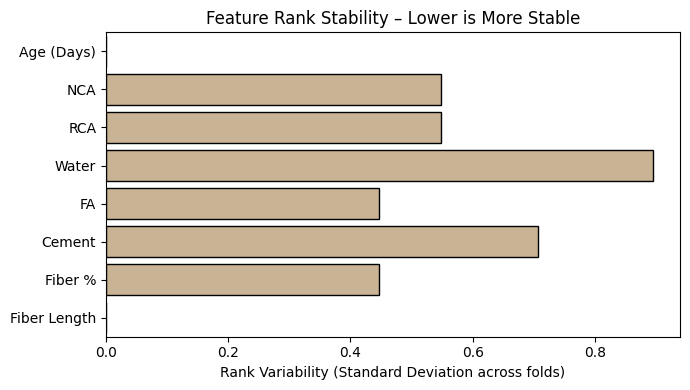

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
summary = pd.read_csv("rank_stability_summary.csv")
summary = summary.sort_values("mean_rank")

plt.figure(figsize=(7,4))
sns.barplot(x="std_rank", y="feature", data=summary, color="tan", edgecolor="black")
plt.xlabel("Rank Variability (Standard Deviation across folds)")
plt.ylabel("")
plt.title("Feature Rank Stability – Lower is More Stable")
plt.tight_layout()
plt.savefig("rank_variability_barplot.png", dpi=600)
plt.show()


**PDP and ALE plots**

  Cloning https://github.com/blent-ai/alepython.git to /tmp/pip-req-build-adkcinov
  Running command git clone --filter=blob:none --quiet https://github.com/blent-ai/alepython.git /tmp/pip-req-build-adkcinov
  Resolved https://github.com/blent-ai/alepython.git to commit 286350ab674980a32270db2a0b5ccca1380312a7
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.5 MB/s eta 0:00:00
  Created wheel for alepython: filename=alepython-0.1.dev17+g286350ab6-py3-none-any.whl size=15251 sha256=3e20f625a3e7601cb07262eafd3ef4e8fccc412e642efce4cb2d0641726c1f4a
  Stored in directory: /tmp/pip-ephem-wheel-cache-rx_io6co/wheels/d2/e1/e3/33b45167b4ec4d2c323f275b00b998330ca43c81c9266a63be
Successfully built alepython
Locked 30% Test — R²=0.9501, RMSE=3.830 MPa, MAE=2.578 MPa
Saved PDP figure: xgb_pso_pdp_all/pdp_all_features.png


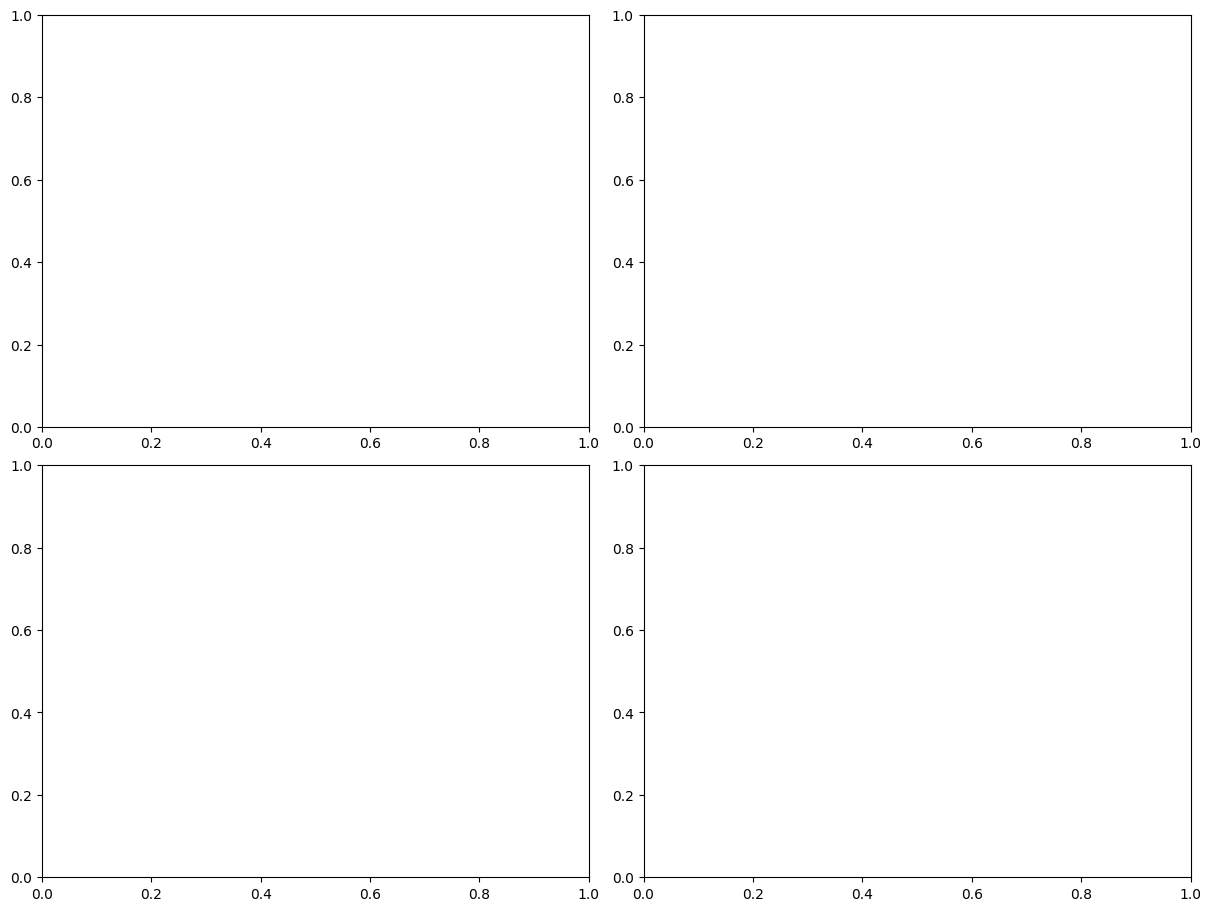

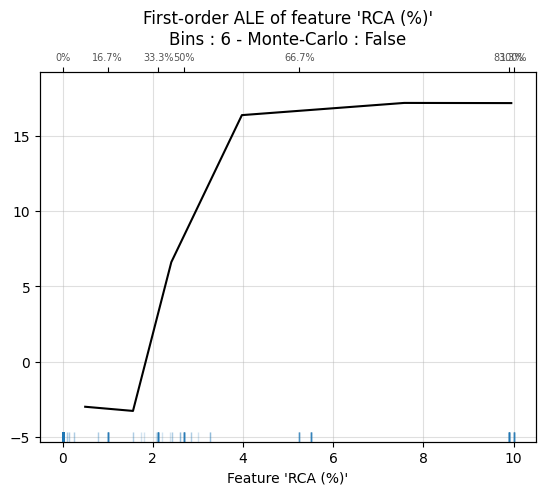

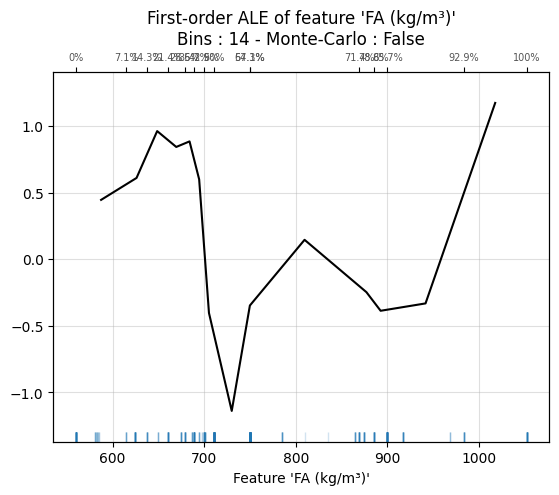

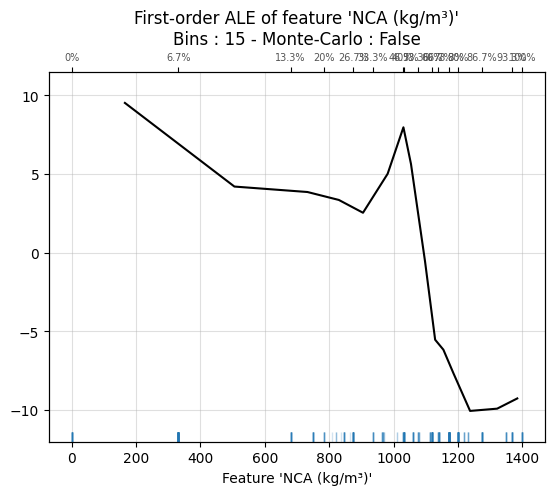

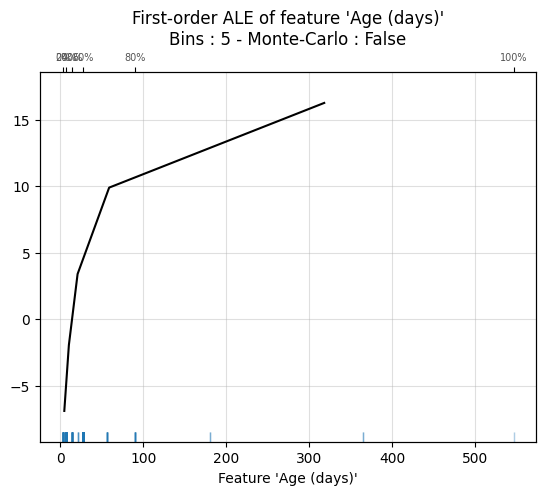

Saved: xgb_pso_pdp_all/pdp_all_features.png and xgb_pso_pdp_all/ale_top4.png


In [4]:
!pip install git+https://github.com/blent-ai/alepython.git  # if needed for alepython

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay

try:
    from alepython import ale_plot
except ImportError as e:
    raise ImportError("alepython is not installed. Uncomment the pip line at the top and run it.") from e

OUT_DIR = "xgb_pso_pdp_all"
os.makedirs(OUT_DIR, exist_ok=True)

FINAL_HP = dict(
    objective="reg:squarederror", eval_metric="rmse",
    max_depth=6, learning_rate=0.15029952891079157, n_estimators=438,
    subsample=0.7134969688114298, colsample_bytree=0.6316935627272379,
    min_child_weight=3, random_state=42, n_jobs=-1, verbosity=0
)

DF_PATH = "Coconut fiber data.xlsx"
TARGET_CANDIDATES = ["Compressive Strength (MPa)", "Compressive Strength"]  # robust to your header

df = pd.read_excel(DF_PATH)

TARGET = None
for c in TARGET_CANDIDATES:
    if c in df.columns:
        TARGET = c
        break
if TARGET is None:
    raise ValueError("Couldn't find target column. Checked: " + ", ".join(TARGET_CANDIDATES))

X = df.drop(columns=[TARGET])
y = df[TARGET]

train_idx = np.load("train_idx.npy")
test_idx  = np.load("test_idx.npy")
X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

model = xgb.XGBRegressor(**FINAL_HP)
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
r2  = r2_score(y_test, y_pred_test)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred_test)))
mae  = mean_absolute_error(y_test, y_pred_test)
print(f"Locked 30% Test — R²={r2:.4f}, RMSE={rmse:.3f} MPa, MAE={mae:.3f} MPa")

#PDP
features = list(X_train.columns)

n_features = len(features)
n_cols = 2 if n_features <= 8 else 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 3.6*n_rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

BROWN = "#8B5A2B"
line_style = {"color": BROWN, "linewidth": 2.5}

for ax, feat in zip(axes, features):
    PartialDependenceDisplay.from_estimator(
        model,
        X_train,
        features=[feat],
        ax=ax,
        line_kw=line_style
    )
    ax.set_title(f"PDP: {feat}", fontsize=11)
    ax.set_ylabel("Partial dependence (MPa)")
    ax.grid(alpha=0.25)

for k in range(len(features), len(axes)):
    fig.delaxes(axes[k])

ymins, ymaxs = [], []
for ax in fig.get_axes():
    if len(ax.lines) > 0:
        y0, y1 = ax.get_ylim()
        ymins.append(y0); ymaxs.append(y1)
if ymins and ymaxs:
    common_min, common_max = min(ymins), max(ymaxs)
    for ax in fig.get_axes():
        if len(ax.lines) > 0:
            ax.set_ylim(common_min, common_max)

fig.suptitle("Partial Dependence (PDP) — Final XGB-PSO", fontsize=13)
pdp_path = f"{OUT_DIR}/pdp_all_features.png"
fig.savefig(pdp_path, dpi=600, bbox_inches="tight")
plt.close(fig)
print("Saved PDP figure:", pdp_path)

#ALE (Top 4 by feature importance)
importances = model.feature_importances_
order = np.argsort(importances)[::-1]
top_n = min(4, len(features))
TOP4 = [features[i] for i in order[:top_n]]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < len(TOP4):
        feat = TOP4[i]
        tmp_ax = ale_plot(model, X_train, feat, bins=20)
        tmp_fig = tmp_ax.figure

        if tmp_ax.lines:
            xdata = tmp_ax.lines[0].get_xdata()
            ydata = tmp_ax.lines[0].get_ydata()
            ax.plot(xdata, ydata, color=BROWN, linewidth=2.5)
        else:
            print(f"[WARN] No ALE line found for feature '{feat}'.")

        ax.set_title(f"ALE: {feat}", fontsize=11)
        ax.set_xlabel(feat)
        ax.set_ylabel("ALE effect (MPa)")
        ax.grid(alpha=0.25)

        plt.close(tmp_fig)
    else:
        fig.delaxes(ax)

valid_axes = [ax for ax in fig.get_axes() if len(ax.lines) > 0]
if valid_axes:
    ymins, ymaxs = zip(*[ax.get_ylim() for ax in valid_axes])
    ymin_common, ymax_common = min(ymins), max(ymaxs)
    for ax in valid_axes:
        ax.set_ylim(ymin_common, ymax_common)

fig.suptitle("Accumulated Local Effects (ALE)", fontsize=12)
ale_path = f"{OUT_DIR}/ale_top4.png"
fig.savefig(ale_path, dpi=600, bbox_inches="tight")
plt.close(fig)

print("Saved:", pdp_path, "and", ale_path)


**ICE Plots**

In [ ]:

import os, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
import xgboost as xgb

OUT_DIR = "xgb_pso_ice_final"
os.makedirs(OUT_DIR, exist_ok=True)

DF_PATH = "Coconut fiber data.xlsx"
TARGET = "Compressive Strength (MPa)"

df = pd.read_excel(DF_PATH)
X = df.drop(columns=[TARGET])
y = df[TARGET]

train_idx = np.load("train_idx.npy")
test_idx  = np.load("test_idx.npy")

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

FINAL_HP = dict(
    objective="reg:squarederror", eval_metric="rmse",
    max_depth=6, learning_rate=0.15029952891079157, n_estimators=438,
    subsample=0.7134969688114298, colsample_bytree=0.6316935627272379,
    min_child_weight=3, random_state=42, n_jobs=-1, verbosity=0
)

model = xgb.XGBRegressor(**FINAL_HP)
model.fit(X_train, y_train)

features = list(X_train.columns)
n = len(features)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.5*nrows))
axes = np.array(axes).reshape(-1)

brown = "#8B5A2B"
subsample = min(200, len(X_train))

ymins, ymaxs = [], []

for i, feat in enumerate(features):
    disp = PartialDependenceDisplay.from_estimator(
        model,
        X_train,
        features=[feat],
        kind="individual",
        subsample=subsample,
        grid_resolution=100,
        line_kw={"color": brown, "alpha": 0.35, "linewidth": 1.2},
        ax=axes[i]
    )
    axes[i].set_title(f"ICE: {feat}", fontsize=12)
    axes[i].set_ylabel("Predicted CS (MPa)", fontsize=11)
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].grid(alpha=0.2)
    ymins.append(axes[i].get_ylim()[0])
    ymaxs.append(axes[i].get_ylim()[1])

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

common_ymin, common_ymax = min(ymins), max(ymaxs)
for k in range(i+1):
    axes[k].set_ylim(common_ymin, common_ymax)

fig.suptitle("Individual Conditional Expectation (ICE)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(f"{OUT_DIR}/ice_all_features.png", dpi=600, bbox_inches="tight")
plt.close(fig)

print("Saved:", f"{OUT_DIR}/ice_all_features.png")


Saved: xgb_pso_ice_final/ice_all_features.png


**Taylor Diagram**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.grid_finder as gf
import mpl_toolkits.axisartist.floating_axes as fa

class TaylorDiagram:
    def __init__(self, obs_std, fig=None, rect=111, label='Actual'):
        self.obs_std = float(obs_std)

        tr = PolarAxes.PolarTransform()

        rlocs = np.array([0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,1.0])
        tlocs = np.arccos(rlocs)                # polar angle
        gl1 = gf.FixedLocator(tlocs)
        tf1 = gf.DictFormatter(dict(zip(tlocs, [f"{r:.2g}" for r in rlocs])))

        self.smin, self.smax = 0, 1.6*self.obs_std

        gh = fa.GridHelperCurveLinear(
            tr, extremes=(0, np.pi/2, self.smin, self.smax),
            grid_locator1=gl1, tick_formatter1=tf1
        )

        if fig is None:
            fig = plt.figure(figsize=(8.8, 8.0))
        ax = fa.FloatingSubplot(fig, rect, grid_helper=gh)
        fig.add_subplot(ax)

        # angle axis (correlation)
        ax.axis['top'].set_axis_direction('bottom')
        ax.axis['top'].toggle(ticklabels=True, label=True)
        ax.axis['top'].major_ticklabels.set_axis_direction('top')
        ax.axis['top'].label.set_axis_direction('top')
        ax.axis['top'].label.set_text("Correlation coefficient")
        ax.axis['top'].label.set_fontsize(16)
        ax.axis['top'].major_ticklabels.set_fontsize(12)

        # measured SD (x) and simulated SD (y)
        ax.axis['left'].set_axis_direction('bottom')
        ax.axis['left'].toggle(ticklabels=True, label=True)
        ax.axis['left'].label.set_text("Measured Standard Deviation")
        ax.axis['left'].label.set_fontsize(15)
        ax.axis['left'].major_ticklabels.set_fontsize(12)

        ax.axis['right'].set_axis_direction('top')
        ax.axis['right'].toggle(ticklabels=True, label=True)
        ax.axis['right'].label.set_text("Simulated Standard Deviation")
        ax.axis['right'].label.set_fontsize(15)
        ax.axis['right'].major_ticklabels.set_fontsize(12)

        ax.axis['bottom'].set_visible(False)
        ax.grid(alpha=0.25)
        self._ax = ax
        self.ax = ax.get_aux_axes(tr)

        # reference star (observed) and its SD arc
        self.ref, = self.ax.plot([0], [self.obs_std], 'k*', ms=12, label=label)
        t = np.linspace(0, np.pi/2, 200)
        self.ax.plot(t, np.full_like(t, self.obs_std), 'k--', lw=1.0)
        self.ax.text(0.04, self.obs_std * 1.21, "Reference (Actual)",
             fontsize=12, ha='center', va='center')

        self.samplePoints = [self.ref]

    def add_sample(self, std, corr, **kwargs):
        l, = self.ax.plot(np.arccos(corr), std, **kwargs)
        self.samplePoints.append(l)
        return l

    def add_rmse_contours(self, levels=(4, 6, 9, 12, 18, 24, 30), **kwargs):
        rs, ts = np.meshgrid(
            np.linspace(self.smin, self.smax, 200),
            np.linspace(0, np.pi/2, 200)
        )
        rmse = np.sqrt(self.obs_std**2 + rs**2 - 2*self.obs_std*rs*np.cos(ts))
        cs = self.ax.contour(ts, rs, rmse, levels=levels,
                             colors='0.35', linewidths=1.2, **kwargs)

        self.ax.clabel(cs, inline=True, fmt=r"RMSE=%g", fontsize=11)
        return cs

def draw_taylor(obs_std, series, title="Taylor Diagram — Test Set", outfile="taylor_test.png"):
    """
    series: list of dicts with keys:
      name, std, corr, marker, mfc, mec
    """
    fig = plt.figure(figsize=(8.8, 8.0))
    dia = TaylorDiagram(obs_std, fig=fig, rect=111, label="Actual")

    dia.add_rmse_contours()
    handles = []
    labels  = []
    for s in series:
        h = dia.add_sample(
            std=s["std"], corr=s["corr"],
            marker=s.get("marker", "o"),
            ms=10, mfc=s.get("mfc","none"), mec=s.get("mec","k"),
            mew=2.0, linestyle=''
        )
        handles.append(h); labels.append(s["name"])

    leg = fig.legend(handles, labels, loc='upper right',
                     bbox_to_anchor=(0.98, 0.98), frameon=True,
                     framealpha=0.9, facecolor='white', edgecolor='0.7',
                     fontsize=12, ncol=1, borderpad=0.6, labelspacing=0.4)

    fig.suptitle(title, fontsize=18, y=0.95)
    plt.savefig(outfile, dpi=600, bbox_inches="tight")
    plt.close(fig)
    print(f"saved: {outfile}")

obsSTD = 17.20
series = [
    {"name":"SVM-PSO", "std":17.13, "corr":0.967, "marker":"^", "mfc":"none", "mec":"#7db0ff"},
    {"name":"KNN-PSO", "std":17.14, "corr":0.952, "marker":"o", "mfc":"none", "mec":"#ff8fb1"},
    {"name":"RF-PSO",  "std":15.90, "corr":0.972, "marker":"s", "mfc":"none", "mec":"lightgreen"},
    {"name":"LGB-PSO", "std":16.88, "corr":0.972, "marker":"v", "mfc":"none", "mec":"yellow"},
    {"name":"XGB-PSO", "std":16.94, "corr":0.975, "marker":"+", "mfc":"none", "mec":"purple"},
    {"name":"ANN-PSO", "std":16.24, "corr":0.958, "marker":">", "mfc":"none", "mec":"lightseagreen"},
]
draw_taylor(obsSTD, series, outfile="taylor_locked_test.png")

/tmp/ipython-input-4235482739.py:12: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  tr = PolarAxes.PolarTransform()
/tmp/ipython-input-4235482739.py:86: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  self.ax.clabel(cs, inline=True, fmt=r"RMSE=%g", fontsize=11)


saved: taylor_locked_test.png


In [ ]:
!pip freeze > requirements.txt

In [ ]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>